In [2]:
## Version 2
# %% [markdown]
# # INFO-F-422 Project: EMG-based Hand Pose Estimation (Guided Gestures)
#
# **Team:** [Your Team Name/Number]
# **Members:** [Your Names]
#
# This notebook implements baseline and neural network approaches for predicting hand joint angles from sEMG signals using the guided gestures dataset.

# %%
# Core Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
import pickle # To save models/results if needed
from contextlib import contextmanager

# Scikit-learn Modules
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler # Key for preprocessing features
from sklearn.impute import SimpleImputer # Example if needed, but unlikely for features
from sklearn.model_selection import GroupKFold, cross_validate, train_test_split, GridSearchCV
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import mean_squared_error, make_scorer, r2_score
from sklearn.linear_model import Ridge, Lasso # Added Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn import set_config # For metadata routing

# PyTorch Modules (for Objective 5)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import gc

# Configure visualizations
%matplotlib inline
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Define a timing context manager for convenience
@contextmanager
def timer(label: str):
    start = time.time()
    print(f"{label}...")
    yield
    end = time.time()
    print(f"{label} done in {end - start:.2f} seconds.\n")

# Configure metadata routing (needed for SFS and potentially CV with params)
set_config(enable_metadata_routing=True)
print(f"Scikit-learn metadata routing enabled: {set_config(True)}") # Confirm it's set

device = torch.device("cpu")
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Original line commented out
print(f"Using device: {device} (CPU forced)")

Scikit-learn metadata routing enabled: None
Using device: cpu (CPU forced)


Raw Training/Validation Data Shapes:
X_train_val_raw: (5, 8, 230000)
y_train_val_raw: (5, 51, 230000)

Raw Test Data Shape (for info):
X_test_raw_info: (5, 332, 8, 500)

Number of Training/Validation Sessions: 5
Number of Electrodes: 8
Number of Time Points per Session: 230000
Number of Joints: 51
Applying Signal Filtering...
Applied DC offset removal and bandpass filtering.
Applying Signal Filtering done in 0.20 seconds.

Window Size (k): 500
Overlap: 75%
Step Size: 125
Creating overlapping windows...
Session 0: Created 1837 windows.
Session 1: Created 1837 windows.
Session 2: Created 1837 windows.
Session 3: Created 1837 windows.
Session 4: Created 1837 windows.
Creating overlapping windows done in 0.08 seconds.


Windowed Data Shapes:
X_windowed: (9185, 8, 500)
y_windowed: (9185, 51)
Groups: (9185,)
Unique groups (sessions): [0 1 2 3 4]
Preprocessing Step: StandardScaler will be applied to extracted features within pipelines and NN CV loop.
Testing Feature Extractor (using canonical

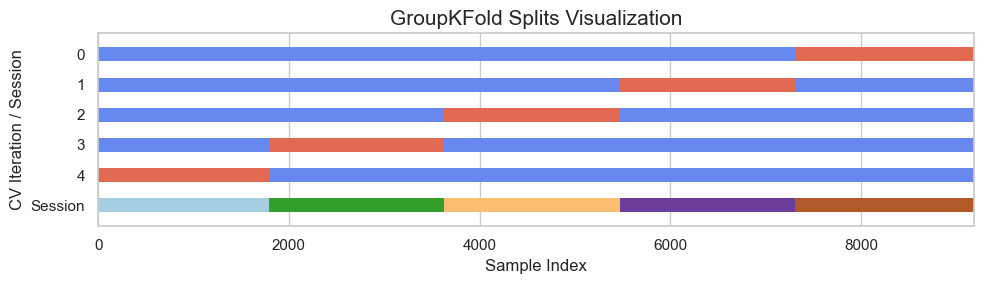

CV Split visualization plot skipped for brevity.
--- Evaluating Baseline Models (Ridge, Lasso, RF) ---
Cross-validating Ridge...
Cross-validating Ridge done in 6.94 seconds.

Cross-validating Lasso...
Cross-validating Lasso done in 15.23 seconds.

Cross-validating RandomForest...
Cross-validating RandomForest done in 18.50 seconds.


Baseline Cross-Validation Performance Results:

--- Ridge ---
  RMSE: 7.0409 +/- 0.6196
  NMSE: 0.2481 +/- 0.0509
  R2 Score: 0.6306 +/- 0.0434
  Avg Fit Time: 4.52s
  Avg Score Time: 1.06s

--- Lasso ---
  RMSE: 7.0256 +/- 0.6066
  NMSE: 0.2470 +/- 0.0494
  R2 Score: 0.5890 +/- 0.0329
  Avg Fit Time: 12.64s
  Avg Score Time: 1.07s

--- RandomForest ---
  RMSE: 4.4161 +/- 0.7237
  NMSE: 0.0994 +/- 0.0346
  R2 Score: 0.7522 +/- 0.0288
  Avg Fit Time: 15.93s
  Avg Score Time: 1.47s

--- Baseline Summary Table ---
       Model     Type  RMSE_mean  RMSE_std  NMSE_mean  NMSE_std  R2_mean  R2_std  FitTime
       Ridge Baseline     7.0409    0.6196     0.2481    

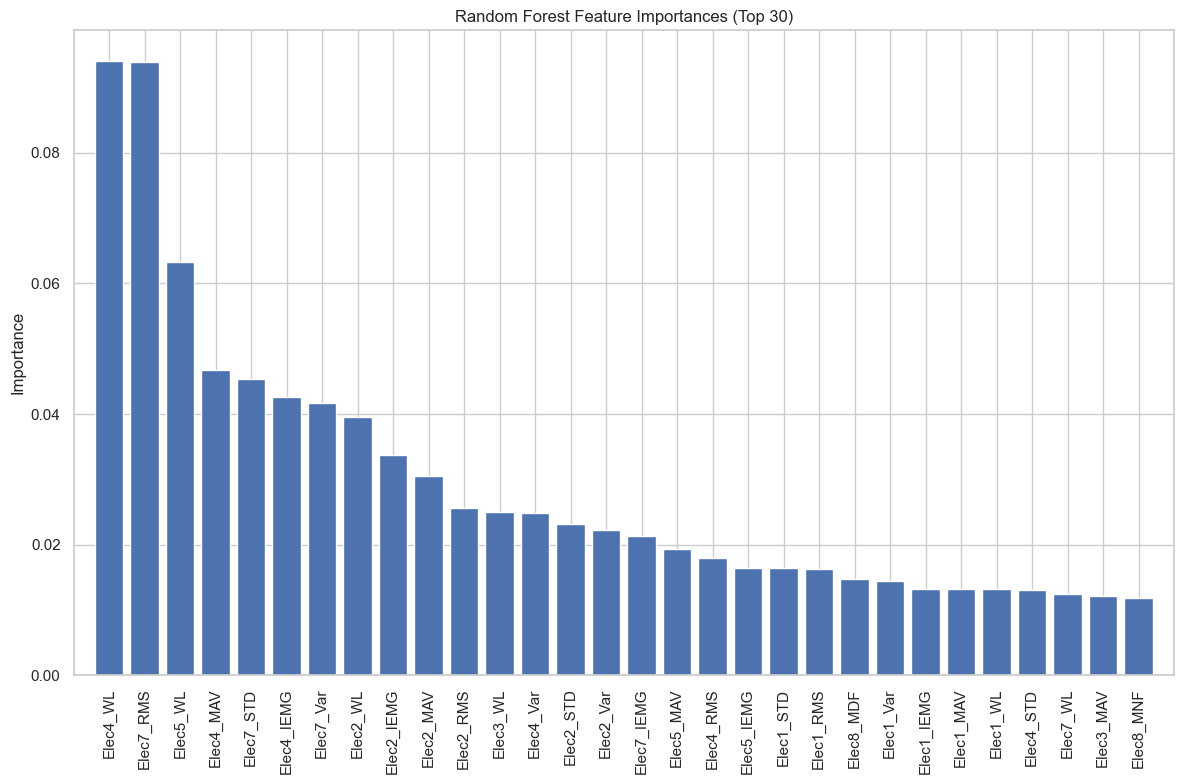


--- Performing Sequential Feature Selection (SFS) ---
Fitting Sequential Feature Selector...
Fitting Sequential Feature Selector done in 372.89 seconds.


SFS selected 38 features out of 88.
Selected Feature Names (first 50):
['Elec1_MAV', 'Elec1_Var', 'Elec1_MPR', 'Elec1_WL', 'Elec1_SSC', 'Elec1_MNF', 'Elec1_MDF', 'Elec2_MAV', 'Elec2_Var', 'Elec2_STD', 'Elec2_ZC', 'Elec2_MPR', 'Elec2_WL', 'Elec2_SSC', 'Elec2_MNF', 'Elec3_RMS', 'Elec3_Var', 'Elec3_ZC', 'Elec3_WL', 'Elec3_SSC', 'Elec3_MNF', 'Elec4_MAV', 'Elec4_Var', 'Elec4_STD', 'Elec4_MPR', 'Elec4_MDF', 'Elec5_WL', 'Elec5_SSC', 'Elec6_ZC', 'Elec7_RMS', 'Elec7_Var', 'Elec7_WL', 'Elec7_IEMG', 'Elec7_MNF', 'Elec7_MDF', 'Elec8_STD', 'Elec8_WL', 'Elec8_MDF']


Counts of selected feature types:
WL      6
Var     5
SSC     4
MNF     4
MDF     4
MAV     3
MPR     3
STD     3
ZC      3
RMS     2
IEMG    1
Name: count, dtype: int64

Counts of selected electrodes:
Elec2    8
Elec1    7
Elec3    6
Elec7    6
Elec4    5
Elec8    3
Elec5    2
Elec6

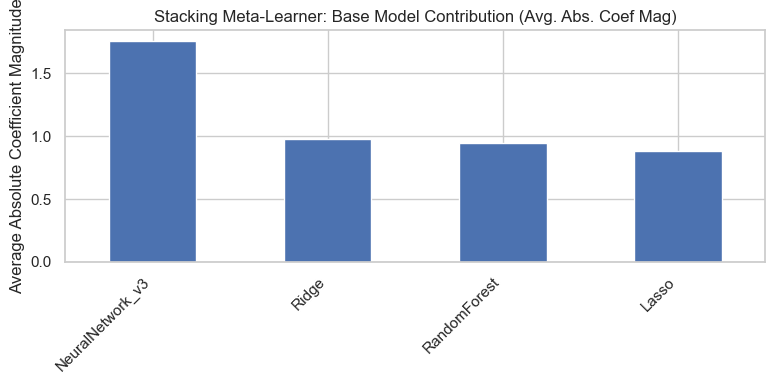


--- Preparing Final Model for Test Set Prediction (Guided Gestures) ---

Final Combined Model Comparison Table (for selection):
           Model          Type  RMSE_mean  RMSE_std  NMSE_mean  NMSE_std        R2_mean  R2_std  FitTime
NeuralNetwork_v3 Sophisticated     3.5891    0.5882        NaN       NaN            NaN     NaN 311.6686
     Stacking_RF      Ensemble     3.6101    0.5996     0.0663    0.0211         0.7700  0.0219   8.7184
  Stacking_Lasso      Ensemble     3.6672    0.5000     0.0676    0.0176         0.7693  0.0210  70.0650
  Stacking_Ridge      Ensemble     4.0543    0.4388     0.0823    0.0174         0.7303  0.0238   0.0241
RandomForest_SFS  Baseline_SFS     4.4037    0.7220     0.0987    0.0340         0.7527  0.0277  15.8525
    RandomForest      Baseline     4.4161    0.7237     0.0994    0.0346         0.7522  0.0288  15.9313
 AverageEnsemble      Ensemble     4.8516       NaN     0.1160       NaN -98684121.9806     NaN      NaN
           Lasso      Baseline 

In [ ]:



# %% [markdown]
# ## 1. Load Data
#
# Load the guided gestures dataset files. (Code identical to previous version)

# %%
# File paths
X_TRAIN_VAL_PATH = "guided_dataset_X.npy"
Y_TRAIN_VAL_PATH = "guided_dataset_y.npy"
X_TEST_PATH = "guided_testset_X.npy"

# Load the training/validation data
X_train_val_raw = np.load(X_TRAIN_VAL_PATH)
y_train_val_raw = np.load(Y_TRAIN_VAL_PATH)

# Load the test data structure description (we need shape info)
X_test_raw_info = np.load(X_TEST_PATH, mmap_mode='r')

# Print shapes to verify
print("Raw Training/Validation Data Shapes:")
print(f"X_train_val_raw: {X_train_val_raw.shape}")
print(f"y_train_val_raw: {y_train_val_raw.shape}")
print("\nRaw Test Data Shape (for info):")
print(f"X_test_raw_info: {X_test_raw_info.shape}")

# Constants derived from data
N_SESSIONS_TRAIN_VAL = X_train_val_raw.shape[0]
N_ELECTRODES = X_train_val_raw.shape[1]
N_TIME_POINTS_TRAIN_VAL = X_train_val_raw.shape[2]
N_JOINTS = y_train_val_raw.shape[1]

print(f"\nNumber of Training/Validation Sessions: {N_SESSIONS_TRAIN_VAL}")
print(f"Number of Electrodes: {N_ELECTRODES}")
print(f"Number of Time Points per Session: {N_TIME_POINTS_TRAIN_VAL}")
print(f"Number of Joints: {N_JOINTS}")

# %% [markdown]
# ## 2. Signal Filtering (Optional but Applied)
#
# Applying band-pass filtering (20-450 Hz) and DC offset removal to the raw sEMG data before windowing.

# %%
# Example (requires scipy):
from scipy.signal import butter, filtfilt

def butter_bandpass(lowcut, highcut, fs, order=5):
     nyq = 0.5 * fs
     low = lowcut / nyq
     high = highcut / nyq
     b, a = butter(order, [low, high], btype='band')
     return b, a

def bandpass_filter(data, lowcut, highcut, fs, order=5):
     b, a = butter_bandpass(lowcut, highcut, fs, order=order)
     # Apply filter along the time axis (axis=-1)
     y = filtfilt(b, a, data, axis=-1)
     return y

FS = 1024 # Sampling frequency from documentation
LOWCUT = 20
HIGHCUT = 450

with timer("Applying Signal Filtering"):
    X_train_val_filtered = np.zeros_like(X_train_val_raw)
    for i in range(N_SESSIONS_TRAIN_VAL):
        # Remove DC offset (mean) per channel
        dc_removed = X_train_val_raw[i] - np.mean(X_train_val_raw[i], axis=-1, keepdims=True)
        # Apply bandpass filter
        X_train_val_filtered[i] = bandpass_filter(dc_removed, LOWCUT, HIGHCUT, FS)

    X_train_val_to_window = X_train_val_filtered
    print("Applied DC offset removal and bandpass filtering.")



# %% [markdown]
# ## 3. Dataset Preparation: Overlapping Windows (Objective 2)
#
# Segment the filtered sEMG and raw joint angle data into overlapping windows. (Code identical to previous version)

# %%
# Windowing Parameters
WINDOW_SIZE = 500  # k
OVERLAP_PERCENTAGE = 0.75 # Using 50% overlap

step = int(WINDOW_SIZE * (1 - OVERLAP_PERCENTAGE))
if step == 0:
    raise ValueError("Overlap percentage cannot be 100%")
print(f"Window Size (k): {WINDOW_SIZE}")
print(f"Overlap: {OVERLAP_PERCENTAGE*100:.0f}%")
print(f"Step Size: {step}")

# (create_overlapping_windows function definition is the same as before)
def create_overlapping_windows(X_raw, y_raw, window_size, step):
    n_sessions, n_electrodes, n_timepoints = X_raw.shape
    n_joints = y_raw.shape[1]
    X_windowed_list, y_windowed_list, groups_list = [], [], []
    for session_idx in range(n_sessions):
        session_X = X_raw[session_idx]
        session_y = y_raw[session_idx]
        start_indices = np.arange(0, n_timepoints - window_size + 1, step)
        for start_idx in start_indices:
            end_idx = start_idx + window_size
            window_X = session_X[:, start_idx:end_idx]
            target_y = session_y[:, end_idx - 1]
            X_windowed_list.append(window_X)
            y_windowed_list.append(target_y)
            groups_list.append(session_idx)
        print(f"Session {session_idx}: Created {len(start_indices)} windows.")
    return np.stack(X_windowed_list), np.stack(y_windowed_list), np.array(groups_list)


# Create the windowed dataset
with timer("Creating overlapping windows"):
    X_windowed, y_windowed, groups = create_overlapping_windows(
        X_train_val_to_window, y_train_val_raw, WINDOW_SIZE, step
    )

print("\nWindowed Data Shapes:")
print(f"X_windowed: {X_windowed.shape}")
print(f"y_windowed: {y_windowed.shape}")
print(f"Groups: {groups.shape}")
print(f"Unique groups (sessions): {np.unique(groups)}")


# %% [markdown]
# ## 4. Data Preprocessing (Features)
#
# The primary preprocessing step after feature extraction is **normalization/scaling**. We use `StandardScaler` to standardize features by removing the mean and scaling to unit variance. This is crucial for distance-based algorithms, linear models (Ridge, Lasso), and neural networks.
#
# **Missing Values:** The `EMGFeatureExtractor` includes `np.nan_to_num` to handle potential issues arising during feature calculation (e.g., variance of a constant signal is zero, leading to NaN in STD if not handled). We assume the raw EMG or windowed data does not contain NaNs initially.
#
# **Outliers:** We are not applying explicit outlier removal at this stage. `StandardScaler` is somewhat sensitive to outliers, but EMG signals can naturally have spikes. Robust scaling methods (like `RobustScaler`) could be considered if outlier impact is significant.
#
# **Implementation:** `StandardScaler` will be included *within* the Scikit-learn pipelines for baseline models and applied explicitly during the Neural Network's cross-validation loop to prevent data leakage.

# %%
print("Preprocessing Step: StandardScaler will be applied to extracted features within pipelines and NN CV loop.")
# Example: If you wanted to check features *before* scaling (optional)
# temp_extractor = EMGFeatureExtractor()
# temp_features = temp_extractor.fit_transform(X_windowed)
# print(f"Feature shape before scaling: {temp_features.shape}")
# print(f"Example features mean (before scaling): {np.mean(temp_features[:, 0]):.4f}")
# print(f"Example features std (before scaling): {np.std(temp_features[:, 0]):.4f}")
# del temp_extractor, temp_features # Clean up




# %% [markdown]
# ## 5. Custom Feature Extractor (Baseline - Objective 4)

# %%
import scipy.fftpack # Ensure this is imported if not already at the top

class EMGFeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, zc_threshold=1e-5, ssc_threshold=1e-5, selected_features=None, verbose=False): # Added verbose from your other version
        # Rule for sklearn: Store parameters passed to __init__ as attributes with the exact same names
        self.zc_threshold = zc_threshold
        self.ssc_threshold = ssc_threshold
        self.selected_features = selected_features # <<< STORE THE PARAMETER DIRECTLY
        self.verbose = verbose # Added from your other version

        # You can still have internal attributes for derived values if needed,
        # but the original parameters must be stored.
        self.all_available_feature_names = ['MAV', 'RMS', 'Var', 'STD', 'ZC', 'MPR', 'WL', 'SSC', 'IEMG', 'MNF', 'MDF']

        # The logic to determine the actual features to extract can go into `fit`
        # or an internal helper method called by `fit`.
        # For now, we'll define _features_to_extract in fit.

    def _resolve_features_to_extract(self):
        """
        Internal helper to determine the actual list of features to use based on self.selected_features.
        This logic was previously in __init__.
        """
        if self.selected_features is None:
            # Default to all available features if none were specified in __init__
            return self.all_available_feature_names
        else:
            # Ensure it's a list-like structure if it came from selected_features
            current_selection = list(self.selected_features)
            # Validate selected features against all_available_feature_names
            for f in current_selection:
                if f not in self.all_available_feature_names:
                    raise ValueError(f"Invalid feature '{f}'. Allowed features are: {self.all_available_feature_names}")
            # If selected_features was provided, use that validated list
            return sorted(list(set(current_selection))) # Ensure uniqueness and sort for consistency

    def fit(self, X, y=None):
        # Resolve the actual features to extract here, based on self.selected_features
        self._actual_features_to_extract = self._resolve_features_to_extract()
        if self.verbose:
            print(f"Feature Extractor fit. Actual features to extract: {self._actual_features_to_extract}")
        return self

    def transform(self, X):
        # Ensure fit has been called (e.g., if used outside a pipeline directly)
        if not hasattr(self, '_actual_features_to_extract'):
            if self.verbose: print("Warning: fit() not called before transform(). Calling fit() now.")
            self.fit(X) # Call fit to set _actual_features_to_extract

        n_windows, n_electrodes, window_size = X.shape
        n_selected = len(self._actual_features_to_extract)

        if n_selected == 0:
            if self.verbose: print("Warning: No features to extract based on selection criteria.")
            return np.empty((n_windows, 0))

        features_data = np.zeros((n_windows, n_electrodes * n_selected))

        for i in range(n_windows):
            current_window_channel_features_list = []
            for j in range(n_electrodes):
                channel_data = X[i, j, :]
                single_channel_extracted_features = []

                mav = np.mean(np.abs(channel_data))
                rms = np.sqrt(np.mean(channel_data**2))
                var = np.var(channel_data)
                std = np.sqrt(var) if var >= 0 else 0
                iemg = np.sum(np.abs(channel_data))

                # Assuming FS is globally available
                freqs = np.fft.rfftfreq(window_size, d=1/FS)
                fft_spectrum = np.abs(np.fft.rfft(channel_data))
                power_spectrum = fft_spectrum**2
                total_power = np.sum(power_spectrum)

                if total_power > 1e-9:
                    mnf = np.sum(freqs * power_spectrum) / total_power
                    cumulative_power = np.cumsum(power_spectrum)
                    mdf_index = np.searchsorted(cumulative_power, total_power / 2.0, side='left')
                    mdf = freqs[mdf_index] if mdf_index < len(freqs) else freqs[-1]
                else:
                    mnf = 0.0
                    mdf = 0.0

                # Use a map for cleaner access
                feature_map = {
                    'MAV': mav, 'RMS': rms, 'Var': var, 'STD': std,
                    'ZC': np.sum(np.diff(np.signbit(channel_data - self.zc_threshold)).astype(int) != 0),
                    'MPR': np.mean(np.abs(channel_data) > (std if std > 1e-9 else 1e-9)),
                    'WL': np.sum(np.abs(np.diff(channel_data))),
                    'SSC': np.sum(((np.diff(channel_data)[:-1] > self.ssc_threshold) & (np.diff(channel_data)[1:] < -self.ssc_threshold)) |
                                  ((np.diff(channel_data)[:-1] < -self.ssc_threshold) & (np.diff(channel_data)[1:] > self.ssc_threshold))),
                    'IEMG': iemg, 'MNF': mnf, 'MDF': mdf
                }

                for feature_name in self._actual_features_to_extract: # Use the resolved list from fit
                    single_channel_extracted_features.append(feature_map[feature_name])

                current_window_channel_features_list.extend(single_channel_extracted_features)
            features_data[i, :] = current_window_channel_features_list

        return np.nan_to_num(features_data, nan=0.0, posinf=0.0, neginf=0.0)

    def get_feature_names_out(self, input_features=None):
        # Ensure fit has been called to define _actual_features_to_extract
        if not hasattr(self, '_actual_features_to_extract'):
            # If get_feature_names_out is called on an unfitted instance,
            # we can resolve features based on the init params for temporary use.
            # This is not ideal but can happen.
            # Alternatively, raise an error or call self.fit() here.
            # For now, let's resolve them based on init params for this specific method call.
            temp_actual_features = self._resolve_features_to_extract()
            if self.verbose: print("Warning: get_feature_names_out() called on unfitted instance. Resolving features from init params.")
        else:
            temp_actual_features = self._actual_features_to_extract

        # N_ELECTRODES should be globally defined or passed
        return [f"Elec{j+1}_{feat}" for j in range(N_ELECTRODES) for feat in temp_actual_features]


# Test the feature extractor (on first few windows for speed if needed)
# This part of your test cell for Section 5 would then be:
with timer("Testing Feature Extractor (using canonical definition)"):
     # This instance will extract ALL features defined in all_available_feature_names
     # because selected_features=None by default
     feature_extractor_canonical = EMGFeatureExtractor(verbose=True) # Set verbose to True to see fit output

     # Fit should be called explicitly or as part of a pipeline before transform
     feature_extractor_canonical.fit(X_windowed) # Call fit
     X_features = feature_extractor_canonical.transform(X_windowed)

X_input_for_nn_cv = X_features
n_input_features = X_input_for_nn_cv.shape[1]

print("Feature Matrix Shape (using canonical extractor):")
print(f"X_features: {X_features.shape}")
# Use _actual_features_to_extract for the expected count after fit
n_expected_features = N_ELECTRODES * len(feature_extractor_canonical._actual_features_to_extract)
print(f"Expected number of features per window: {n_expected_features}")
assert X_features.shape[1] == n_expected_features, "Feature dimension mismatch!"
feature_names = feature_extractor_canonical.get_feature_names_out() # This will now use _actual_features_to_extract
print(f"\nGenerated {len(feature_names)} feature names. Examples: {feature_names[:5]}")
# %% [markdown]
# ## 6. Cross-Validation Strategy (Objective 3)
#
# Using `GroupKFold` with session IDs as groups (Leave-One-Session-Out). (Code identical to previous version)

# %%
N_SPLITS = N_SESSIONS_TRAIN_VAL # Use Leave-One-Session-Out
cv_strategy = GroupKFold(n_splits=N_SPLITS)
print(f"Using GroupKFold with {N_SPLITS} splits (Leave-One-Session-Out).")

# (plot_cv_indices function definition is the same as before)
def plot_cv_indices(cv, X, y, group, n_splits):
    fig, ax = plt.subplots(1, 1, figsize=(10, 3))
    cmap_data = plt.cm.Paired; cmap_cv = plt.cm.coolwarm
    for i, (train_idx, test_idx) in enumerate(cv.split(X, y, group)):
        indices = np.array([np.nan] * len(X)); indices[test_idx] = 1; indices[train_idx] = 0
        ax.scatter(range(len(indices)), [i + .5] * len(indices), c=indices, marker='_', lw=10, cmap=cmap_cv, vmin=-.2, vmax=1.2)
    ax.scatter(range(len(X)), [i + 1.5] * len(X), c=group, marker='_', lw=10, cmap=cmap_data)
    yticklabels = list(range(n_splits)) + ['Session']
    ax.set(yticks=np.arange(n_splits + 1) + .5, yticklabels=yticklabels, xlabel='Sample Index', ylabel="CV Iteration / Session", ylim=[n_splits + 1.2, -.2], xlim=[0, len(y)])
    ax.set_title('GroupKFold Splits Visualization', fontsize=15); plt.tight_layout(); plt.show()

# Plot for our setup using the generated features X_features
plot_cv_indices(cv_strategy, X_features, y_windowed, groups, N_SPLITS)
# Temporarily disable plotting if it takes too long or isn't needed repeatedly
print("CV Split visualization plot skipped for brevity.")



# %% [markdown]
# ## 7. Baseline Model Training and Evaluation (Objective 4 - Expanded)
#
# We now evaluate Ridge, Lasso, and Random Forest regressors.
# The pipeline includes feature extraction and standardization.

# %%
# Define Performance Metrics (Identical code)
def root_mean_squared_error(y_true, y_pred): return np.sqrt(mean_squared_error(y_true, y_pred))
def normalized_mean_squared_error(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    if y_true.shape != y_pred.shape: raise ValueError("Shape mismatch")
    if y_true.ndim == 1: y_true, y_pred = y_true.reshape(-1, 1), y_pred.reshape(-1, 1)
    numerator = np.sum((y_true - y_pred)**2)
    mean_y_true_per_joint = np.mean(y_true, axis=0)
    denominator = np.sum((y_true - mean_y_true_per_joint)**2)
    return np.inf if denominator == 0 and numerator > 1e-9 else (0.0 if denominator == 0 else numerator / denominator)

scorers = {
    'rmse': make_scorer(root_mean_squared_error, greater_is_better=False),
    'nmse': make_scorer(normalized_mean_squared_error, greater_is_better=False),
    'r2': make_scorer(r2_score)
}

# %%
# Select Models - Adding Lasso
from sklearn.linear_model import Lasso # Ensure import

model_ridge = Ridge(alpha=1.0) # Basic regularization
model_lasso = Lasso(alpha=0.01, max_iter=2000, tol=1e-3) # Lasso needs careful alpha tuning, start low
model_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    n_jobs=-1,
    random_state=42,
    max_features=0.33
)

# Store all baseline models here
baseline_models_to_evaluate = {
    "Ridge": model_ridge,
    "Lasso": model_lasso,
    "RandomForest": model_rf
}

# Store all results here across objectives
all_cv_results = {}

# %%
# Evaluate baseline models using Cross-Validation
print("--- Evaluating Baseline Models (Ridge, Lasso, RF) ---")
for model_name, model in baseline_models_to_evaluate.items():
    with timer(f"Cross-validating {model_name}"):
        pipeline = Pipeline([
            ('feature_extraction', EMGFeatureExtractor()),
            ('scaling', StandardScaler()), # Preprocessing step
            ('regression', model)
        ])

        # Perform cross-validation using params for groups
        scores = cross_validate(
            pipeline,
            X_windowed,         # Input raw windowed data
            y_windowed,         # Target
            cv=cv_strategy,
            scoring=scorers,
            n_jobs=-1,
            return_train_score=False,
            params={'groups': groups} # Pass groups via params
        )
        all_cv_results[model_name] = scores # Store results

# %%
# Display Baseline CV Results
print("\nBaseline Cross-Validation Performance Results:")

results_summary_list = [] # Keep track of summaries
for model_name, scores in all_cv_results.items():
     # Check if model is in the baseline set before printing detailed baseline results
     if model_name in baseline_models_to_evaluate:
        mean_rmse = -np.mean(scores['test_rmse'])
        std_rmse = np.std(scores['test_rmse'])
        mean_nmse = -np.mean(scores['test_nmse'])
        std_nmse = np.std(scores['test_nmse'])
        mean_r2 = np.mean(scores['test_r2'])
        std_r2 = np.std(scores['test_r2'])
        fit_time_mean = np.mean(scores['fit_time'])
        score_time_mean = np.mean(scores['score_time'])

        print(f"\n--- {model_name} ---")
        print(f"  RMSE: {mean_rmse:.4f} +/- {std_rmse:.4f}")
        print(f"  NMSE: {mean_nmse:.4f} +/- {std_nmse:.4f}")
        print(f"  R2 Score: {mean_r2:.4f} +/- {std_r2:.4f}")
        print(f"  Avg Fit Time: {fit_time_mean:.2f}s")
        print(f"  Avg Score Time: {score_time_mean:.2f}s")

        results_summary_list.append({
            'Model': model_name, 'Type': 'Baseline',
            'RMSE_mean': mean_rmse, 'RMSE_std': std_rmse,
            'NMSE_mean': mean_nmse, 'NMSE_std': std_nmse,
            'R2_mean': mean_r2, 'R2_std': std_r2,
            'FitTime': fit_time_mean
        })

# Create a DataFrame for easier comparison later
results_df = pd.DataFrame(results_summary_list)
print("\n--- Baseline Summary Table ---")
print(results_df.to_string(index=False, float_format="%.4f"))


# %% [markdown]
# **Interpretation:**
# - Compare Ridge, Lasso, and Random Forest. Lasso might perform feature selection implicitly (coefficients go to zero). Does it perform better/worse than Ridge or RF? How does its training time compare?
# - *Note:* Lasso's performance is highly dependent on `alpha`. The chosen value `0.01` might need tuning (e.g., using `LassoCV`).


# %% [markdown]
# ## 8. Feature Importance and Selection (Objective 4)
#
# Analyze feature importances for Random Forest and perform Sequential Feature Selection (SFS) using Ridge as the estimator.

# %%
# Feature Importances (for Random Forest) - Requires scaled features

# Create pipeline steps manually ONLY for this analysis
# Note: Re-extracting features here. Could optimize if memory is tight.
analysis_pipeline = Pipeline([
    ('feature_extraction', EMGFeatureExtractor()),
    ('scaling', StandardScaler())
])

# Fit and transform the full training data for analysis
with timer("Extracting & Scaling features for Importance/SFS Analysis"):
    X_features_scaled_for_analysis = analysis_pipeline.fit_transform(X_windowed, y_windowed)
    feature_names_analysis = analysis_pipeline.named_steps['feature_extraction'].get_feature_names_out()
    print(f"Shape of features for analysis: {X_features_scaled_for_analysis.shape}")

# Re-train the Random Forest model on these scaled features if needed for importance
# Or use the one trained inside the CV loop if accessible (less clean)
with timer("Training RandomForest on full data for Importance Analysis"):
    # Use the instance defined earlier
    model_rf.fit(X_features_scaled_for_analysis, y_windowed)

# Get and plot feature importances
importances = model_rf.feature_importances_
indices = np.argsort(importances)[::-1]
print("\nRandom Forest Feature Importances (Top 30):")
n_top_features = 30
for i in range(min(n_top_features, len(importances))):
    print(f"{i + 1}. Feature: {feature_names_analysis[indices[i]]} ({importances[indices[i]]:.4f})")

plt.figure(figsize=(12, 8))
plt.title("Random Forest Feature Importances (Top 30)")
plt.bar(range(min(n_top_features, len(importances))), importances[indices[:n_top_features]], align='center')
plt.xticks(range(min(n_top_features, len(importances))), [feature_names_analysis[i] for i in indices[:n_top_features]], rotation=90)
plt.xlim([-1, min(n_top_features, len(importances))]); plt.ylabel("Importance"); plt.tight_layout(); plt.show()

# %%
# Feature Selection using SFS
print("\n--- Performing Sequential Feature Selection (SFS) ---")
# Configure SFS
sfs = SequentialFeatureSelector(
    estimator=Ridge(alpha=1.0), # Use Ridge for speed
    n_features_to_select='auto',
    tol=1e-4, # Stop if score improvement is less than this (avoids selecting too many minor features)
    direction='forward',
    scoring=scorers['rmse'], # Minimize RMSE (maximize negative RMSE)
    cv=cv_strategy,
    n_jobs=-1
)

# Fit SFS using the scaled features and pass groups via metadata routing
with timer("Fitting Sequential Feature Selector"):
    sfs.fit(X_features_scaled_for_analysis, y_windowed, groups=groups)

# Get selected features
selected_feature_indices = sfs.get_support(indices=True)
selected_feature_names = [feature_names_analysis[i] for i in selected_feature_indices]
n_selected_features = len(selected_feature_names)

print(f"\nSFS selected {n_selected_features} features out of {len(feature_names_analysis)}.")
print("Selected Feature Names (first 50):")
print(selected_feature_names[:50]); print("..." if n_selected_features > 50 else "")

if n_selected_features > 0:
    selected_types = [f.split('_')[1] for f in selected_feature_names]
    selected_electrodes = [f.split('_')[0] for f in selected_feature_names]
    print("\nCounts of selected feature types:"); print(pd.Series(selected_types).value_counts())
    print("\nCounts of selected electrodes:"); print(pd.Series(selected_electrodes).value_counts())
else: print("\nWarning: SFS selected 0 features.")



# %% [markdown]
# ## 9. Final Baseline Pipeline with Selected Features (Optional Refinement)
#
# Create and evaluate a pipeline using only the features selected by SFS with the best baseline model. This is often done to see if selection improved performance or simplified the model effectively.

# %%
if n_selected_features > 0 and n_selected_features < len(feature_names_analysis):
    print("\n--- Evaluating Best Baseline Model with SFS Features ---")
    # Determine the best model from initial CV (e.g., based on lowest RMSE)
    # Make sure results_df is populated correctly
    if not results_df.empty:
        best_baseline_model_name = results_df.loc[results_df['RMSE_mean'].idxmin()]['Model']
        print(f"Selected best baseline model: {best_baseline_model_name}")

        if best_baseline_model_name == "Ridge":
            best_model_instance_sfs = Ridge(alpha=1.0)
        elif best_baseline_model_name == "Lasso":
             best_model_instance_sfs = Lasso(alpha=0.01, max_iter=2000, tol=1e-3)
        else: # RandomForest
            best_model_instance_sfs = RandomForestRegressor(
                n_estimators=100, max_depth=15, n_jobs=-1, random_state=42, max_features=0.33
            )

        # Get the base feature types selected by SFS
        selected_feature_types_only = sorted(list(set( f.split('_', 1)[1] for f in selected_feature_names)))
        print(f"\nUsing {len(selected_feature_types_only)} feature types selected by SFS: {selected_feature_types_only}")

        sfs_pipeline = Pipeline([
            ('feature_extraction', EMGFeatureExtractor(selected_features=selected_feature_types_only)),
            ('scaling', StandardScaler()),
            ('regression', best_model_instance_sfs)
        ])

        print("\nEvaluating pipeline with selected features:")
        with timer(f"Cross-validating {best_baseline_model_name} with {n_selected_features} SFS features"):
            sfs_scores = cross_validate(
                sfs_pipeline, X_windowed, y_windowed, cv=cv_strategy, scoring=scorers,
                n_jobs=-1, return_train_score=False, params={'groups': groups}
            )
            all_cv_results[f"{best_baseline_model_name}_SFS"] = sfs_scores # Store results
            model_name_sfs = f"{best_baseline_model_name}_SFS"

            # Add SFS results to summary list
            mean_rmse = -np.mean(sfs_scores['test_rmse']); std_rmse = np.std(sfs_scores['test_rmse'])
            mean_nmse = -np.mean(sfs_scores['test_nmse']); std_nmse = np.std(sfs_scores['test_nmse'])
            mean_r2 = np.mean(sfs_scores['test_r2']); std_r2 = np.std(sfs_scores['test_r2'])
            fit_time_mean = np.mean(sfs_scores['fit_time']); score_time_mean = np.mean(sfs_scores['score_time'])

            print(f"\n--- {model_name_sfs} ---")
            print(f"  RMSE: {mean_rmse:.4f} +/- {std_rmse:.4f}")
            print(f"  NMSE: {mean_nmse:.4f} +/- {std_nmse:.4f}")
            print(f"  R2 Score: {mean_r2:.4f} +/- {std_r2:.4f}")

            results_summary_list.append({
                'Model': model_name_sfs, 'Type': 'Baseline_SFS',
                'RMSE_mean': mean_rmse, 'RMSE_std': std_rmse, 'NMSE_mean': mean_nmse,
                'NMSE_std': std_nmse, 'R2_mean': mean_r2, 'R2_std': std_r2,
                'FitTime': fit_time_mean
            })
            # Update results_df
            results_df = pd.DataFrame(results_summary_list)

    else:
        print("Skipping SFS pipeline evaluation as baseline results are missing.")
else:
    print("\nSkipping evaluation with SFS features (SFS selected 0 or all features).")

# %% [markdown]
# ## 10. Sophisticated NN – v3 (3 couches + régularisation)
# Remplacez entièrement l’ancienne section 10 par ce bloc.

# %%
# ---------- Helpers ----------
def train_nn_epoch(model, loader, crit, opt, device): # Already defined, ensure this is the one used
    model.train(); run = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        opt.zero_grad(); out = model(x); loss = crit(out, y)
        loss.backward(); opt.step(); run += loss.item() * x.size(0)
    return run / len(loader.dataset)

def evaluate_nn(model, loader, crit, device): # Already defined, ensure this is the one used
    model.eval(); run = 0.0; preds_list = []; trg_list = [] # Renamed to avoid conflict
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x); loss = crit(out, y)
            run += loss.item() * x.size(0)
            preds_list.append(out.cpu().numpy()); trg_list.append(y.cpu().numpy())
    mse = run / len(loader.dataset)
    return mse, np.concatenate(preds_list), np.concatenate(trg_list)

# ---------- Architecture (This is our canonical EMG_NN for sophisticated approach and ensembling) ----------
import torch.nn.functional as F
class EMG_NN(nn.Module): # THIS IS NOW THE CANONICAL EMG_NN class
    def __init__(self, n_features, n_joints,
                 hidden=(256, 128, 64), dropout_p=0.2): # Default values from best_cfg
        super().__init__()
        h1, h2, h3 = hidden
        self.fc1, self.bn1 = nn.Linear(n_features, h1), nn.BatchNorm1d(h1)
        self.fc2, self.bn2 = nn.Linear(h1, h2), nn.BatchNorm1d(h2)
        self.fc3, self.bn3 = nn.Linear(h2, h3), nn.BatchNorm1d(h3)
        self.out = nn.Linear(h3, n_joints)
        self.drop = nn.Dropout(dropout_p)
    def forward(self, x):
        x = self.drop(F.relu(self.bn1(self.fc1(x))))
        x = self.drop(F.relu(self.bn2(self.fc2(x))))
        x = self.drop(F.relu(self.bn3(self.fc3(x))))
        return self.out(x)

# ---------- Early-Stopping ----------
class EarlyStop: # Already defined
    def __init__(self, patience=20):
        self.best = float('inf'); self.pat = patience; self.cnt = 0
    def __call__(self, val):
        if val < self.best - 1e-4: self.best, self.cnt = val, 0
        else: self.cnt += 1
        return self.cnt > self.pat

# ---------- Hyper-paramètres ----------
MAX_EPOCHS_NN_V3   = 150      # Specific to NN_v3
BATCH_SIZE_NN_V3   = 256    # Specific to NN_v3
LR_NN_V3           = 1e-3     # Specific to NN_v3
WEIGHT_DECAY_NN_V3 = 5e-5  # Specific to NN_v3
PATIENCE_LR_NN_V3  = 12     # Specific to NN_v3
PATIENCE_ES_NN_V3  = 20     # Specific to NN_v3

# ---------- Mini-grid 80/20 ----------
print("--- NN-v3: Mini-Grid Hyperparameter Search ---")
mini_grid = [
    {"hidden": (128, 64, 32), "dropout": 0.2},
    {"hidden": (256, 128, 64), "dropout": 0.2},
    # Add more configurations if desired
]

best_cfg_nn_v3, best_rmse_nn_v3 = None, float('inf')
# Ensure X_input_for_nn_cv is from the canonical feature extractor (done in Sec 5)
for cfg_idx, cfg in enumerate(mini_grid):
    print(f"Testing NN-v3 config {cfg_idx+1}/{len(mini_grid)}: {cfg}")
    # Use train_test_split on the full X_input_for_nn_cv for this hyperparameter search
    Xtr_nn, Xva_nn, ytr_nn, yva_nn = train_test_split(
        X_input_for_nn_cv, y_windowed, test_size=0.2, random_state=42, stratify=groups
        # Stratify by groups if possible and meaningful for a simple split, though GroupKFold is better for final CV
    )

    sc_nn_grid = StandardScaler()
    Xtr_nn_scaled = sc_nn_grid.fit_transform(Xtr_nn)
    Xva_nn_scaled = sc_nn_grid.transform(Xva_nn)

    tr_ld_nn = DataLoader(TensorDataset(torch.tensor(Xtr_nn_scaled).float(), torch.tensor(ytr_nn).float()),
                          batch_size=BATCH_SIZE_NN_V3, shuffle=True, num_workers=2, pin_memory=False)
    va_ld_nn = DataLoader(TensorDataset(torch.tensor(Xva_nn_scaled).float(), torch.tensor(yva_nn).float()),
                          batch_size=BATCH_SIZE_NN_V3, num_workers=2, pin_memory=False)

    model_nn_grid = EMG_NN(Xtr_nn_scaled.shape[1], N_JOINTS, # Use this EMG_NN
                           hidden=cfg['hidden'], dropout_p=cfg['dropout']).to(device)
    opt_nn_grid  = torch.optim.Adam(model_nn_grid.parameters(), lr=LR_NN_V3, weight_decay=WEIGHT_DECAY_NN_V3)
    sch_nn_grid  = torch.optim.lr_scheduler.ReduceLROnPlateau(opt_nn_grid, patience=PATIENCE_LR_NN_V3, factor=0.5, verbose=False)
    es_nn_grid   = EarlyStop(PATIENCE_ES_NN_V3)

    for epoch_grid in range(MAX_EPOCHS_NN_V3):
        train_nn_epoch(model_nn_grid, tr_ld_nn, nn.MSELoss(), opt_nn_grid, device)
        mse_val_grid, _, _ = evaluate_nn(model_nn_grid, va_ld_nn, nn.MSELoss(), device)
        sch_nn_grid.step(mse_val_grid)
        if es_nn_grid(mse_val_grid):
            print(f" Early stopping at epoch {epoch_grid+1} for config {cfg}")
            break
    rmse_val_grid = mse_val_grid ** 0.5
    print(f" Config {cfg} -> Validation RMSE {rmse_val_grid:.4f}")
    if rmse_val_grid < best_rmse_nn_v3:
        best_rmse_nn_v3, best_cfg_nn_v3 = rmse_val_grid, cfg

print(f"\n✅ NN-v3 Best Config: {best_cfg_nn_v3} (Validation RMSE from grid search: {best_rmse_nn_v3:.4f})")

# ---------- CV 5 folds LOS-O for NN-v3 ----------
print("\n--- NN-v3: Cross-Validation with Best Config ---")
# cv_strategy is GroupKFold(n_splits=N_SPLITS) defined earlier
rmse_folds_nn_v3 = []
fit_times_nn_v3 = []

# Ensure X_input_for_nn_cv is from the canonical feature extractor (done in Sec 5)
for k_fold, (train_idx, val_idx) in enumerate(cv_strategy.split(X_input_for_nn_cv, y_windowed, groups=groups)):
    fold_start_time = time.time()
    print(f"Processing NN-v3 Fold {k_fold+1}/{N_SPLITS}")

    sc_nn_fold = StandardScaler()
    Xtr_fold_nn = sc_nn_fold.fit_transform(X_input_for_nn_cv[train_idx])
    Xva_fold_nn = sc_nn_fold.transform(X_input_for_nn_cv[val_idx])
    ytr_fold_nn, yva_fold_nn = y_windowed[train_idx], y_windowed[val_idx]

    tr_ld_fold_nn = DataLoader(TensorDataset(torch.tensor(Xtr_fold_nn).float(), torch.tensor(ytr_fold_nn).float()),
                               batch_size=BATCH_SIZE_NN_V3, shuffle=True, num_workers=2, pin_memory=False)
    va_ld_fold_nn = DataLoader(TensorDataset(torch.tensor(Xva_fold_nn).float(), torch.tensor(yva_fold_nn).float()),
                               batch_size=BATCH_SIZE_NN_V3, num_workers=2, pin_memory=False)

    model_fold_nn_v3 = EMG_NN(Xtr_fold_nn.shape[1], N_JOINTS, # Use this EMG_NN
                              hidden=best_cfg_nn_v3['hidden'], dropout_p=best_cfg_nn_v3['dropout']).to(device)
    opt_fold_nn_v3 = torch.optim.Adam(model_fold_nn_v3.parameters(), lr=LR_NN_V3, weight_decay=WEIGHT_DECAY_NN_V3)
    sch_fold_nn_v3 = torch.optim.lr_scheduler.ReduceLROnPlateau(opt_fold_nn_v3, patience=PATIENCE_LR_NN_V3, factor=0.5, verbose=False)
    es_fold_nn_v3  = EarlyStop(PATIENCE_ES_NN_V3)

    for epoch_fold in range(MAX_EPOCHS_NN_V3):
        train_nn_epoch(model_fold_nn_v3, tr_ld_fold_nn, nn.MSELoss(), opt_fold_nn_v3, device)
        mse_val_fold, _, _ = evaluate_nn(model_fold_nn_v3, va_ld_fold_nn, nn.MSELoss(), device)
        sch_fold_nn_v3.step(mse_val_fold)
        if es_fold_nn_v3(mse_val_fold):
            print(f" Fold {k_fold+1} early stopping at epoch {epoch_fold+1}")
            break

    # Final evaluation on this fold's validation set
    final_mse_fold, y_pred_fold_nn_v3, y_true_fold_nn_v3 = evaluate_nn(model_fold_nn_v3, va_ld_fold_nn, nn.MSELoss(), device)
    rmse_folds_nn_v3.append(final_mse_fold ** 0.5)

    fold_end_time = time.time()
    fit_times_nn_v3.append(fold_end_time - fold_start_time)
    print(f" Fold {k_fold+1}/{N_SPLITS} -> RMSE {rmse_folds_nn_v3[-1]:.4f}, Time: {fit_times_nn_v3[-1]:.2f}s")

    # Clean up
    del model_fold_nn_v3, tr_ld_fold_nn, va_ld_fold_nn, opt_fold_nn_v3, sch_fold_nn_v3, es_fold_nn_v3
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    gc.collect()


print(f"\n🎯 NN-v3 Mean CV RMSE = {np.mean(rmse_folds_nn_v3):.4f} ± {np.std(rmse_folds_nn_v3):.4f}")

# ---------- Add NN-v3 results to global tables ----------
if 'all_cv_results' not in globals(): all_cv_results = {}
if 'results_summary_list' not in globals(): results_summary_list = []

# For all_cv_results, to be consistent with sklearn's cross_validate output:
all_cv_results['NeuralNetwork_v3'] = {
    'test_rmse': [-rm for rm in rmse_folds_nn_v3], # Store as negative RMSE
    'fit_time': np.array(fit_times_nn_v3),
    # 'test_nmse' and 'test_r2' are not directly calculated here, can be added if needed by evaluating y_pred_fold_nn_v3 vs y_true_fold_nn_v3
}
results_summary_list.append({
    'Model': 'NeuralNetwork_v3', 'Type': 'Sophisticated',
    'RMSE_mean': np.mean(rmse_folds_nn_v3), 'RMSE_std': np.std(rmse_folds_nn_v3),
    'NMSE_mean': np.nan, 'NMSE_std': np.nan, # Not calculated in this loop
    'R2_mean':   np.nan, 'R2_std':   np.nan, # Not calculated in this loop
    'FitTime':   np.mean(fit_times_nn_v3)
})
# Update results_df
results_df = pd.DataFrame(results_summary_list)


# ---------- Final training of NN-v3 on 100% data & save ----------
print("\n--- NN-v3: Final Training on All Data & Saving ---")
sc_final_nn_v3 = StandardScaler()
X_all_nn_v3_scaled = sc_final_nn_v3.fit_transform(X_input_for_nn_cv) # Use all training features

all_ld_nn_v3 = DataLoader(TensorDataset(torch.tensor(X_all_nn_v3_scaled).float(),
                                        torch.tensor(y_windowed).float()),
                          batch_size=BATCH_SIZE_NN_V3, shuffle=True, num_workers=2, pin_memory=False)

final_model_nn_v3 = EMG_NN(X_all_nn_v3_scaled.shape[1], N_JOINTS, # Use this EMG_NN
                           hidden=best_cfg_nn_v3['hidden'], dropout_p=best_cfg_nn_v3['dropout']).to(device)
opt_final_nn_v3 = torch.optim.Adam(final_model_nn_v3.parameters(), lr=LR_NN_V3, weight_decay=WEIGHT_DECAY_NN_V3)
# No scheduler or early stopping for final training on all data, train for full determined epochs or a fixed large number
# OR, train for number of epochs that was typically best during CV, or slightly more.
# Here, we'll train for MAX_EPOCHS_NN_V3 without ES on training loss.
# For early stopping on the training set itself:
# es_final_nn_v3  = EarlyStop(PATIENCE_ES_NN_V3)
# sch_final_nn_v3 = torch.optim.lr_scheduler.ReduceLROnPlateau(opt_final_nn_v3, patience=PATIENCE_LR_NN_V3, factor=0.5, verbose=False)


print(f"Training final NN-v3 model for {MAX_EPOCHS_NN_V3} epochs (or until early stopping on training loss if enabled)...")
with timer(f"Final NN-v3 training"):
    for epoch_final in range(MAX_EPOCHS_NN_V3):
        final_train_loss = train_nn_epoch(final_model_nn_v3, all_ld_nn_v3, nn.MSELoss(), opt_final_nn_v3, device)
        # sch_final_nn_v3.step(final_train_loss) # If using scheduler on training loss
        if (epoch_final + 1) % 10 == 0 or epoch_final == MAX_EPOCHS_NN_V3 -1:
            print(f" Final Training Epoch {epoch_final+1}/{MAX_EPOCHS_NN_V3}, Loss: {final_train_loss:.6f}")
        # if es_final_nn_v3(final_train_loss): # If using early stopping on training loss
        #     print(f" Final training early stopping at epoch {epoch_final+1}")
        #     break

# Save the model and scaler
MODEL_NN_V3_PATH = "final_NN_v3.pth"
SCALER_NN_V3_PATH = "scaler_NN_v3.pkl"
torch.save(final_model_nn_v3.state_dict(), MODEL_NN_V3_PATH)
with open(SCALER_NN_V3_PATH, "wb") as f:
    pickle.dump(sc_final_nn_v3, f)
print(f"💾 NN-v3: Final model saved to {MODEL_NN_V3_PATH} and scaler to {SCALER_NN_V3_PATH}")

# Store for potential use in Objective 7 if it's the best model
# This replaces the generic 'final_trained_model' if NN_v3 is what's being finalized here
final_trained_model_for_obj7 = {'model_type': 'NeuralNetwork_v3',
                                'model': final_model_nn_v3,
                                'scaler': sc_final_nn_v3,
                                'feature_extractor': EMGFeatureExtractor() # To process raw test EMG
                               }
# best_overall_model_name_for_obj7 = 'NeuralNetwork_v3' # Set this if NN_v3 is chosen later

# Ensure the global variables expected by Section 11 are set
final_model = final_model_nn_v3 # Assign to the name expected by Sec 11
sc_fin = sc_final_nn_v3         # Assign to the name expected by Sec 11

# Keep your original saving logic
torch.save(final_model.state_dict(), "final_NN.pth") # Uses 'final_model'
with open("scaler_NN.pkl", "wb") as f: # Uses 'sc_fin'
    pickle.dump(sc_fin, f)
print("💾  Modèle final enregistré dans final_NN.pth et scaler dans scaler_NN.pkl")

# This part is also fine for preparing the dict for later prediction steps
final_trained_model_dict_nn_v3 = {'model': final_model, 'scaler': sc_fin, 'model_type': 'NeuralNetwork_v3', 'feature_extractor': EMGFeatureExtractor()}
# best_overall_model_name = 'NeuralNetwork_v3' # This assignment here might be too early, should be based on results_df

# %% [markdown]
# ## 11. Final Model Selection and Training (Prep for Objective 7)
#
# Based on the combined comparison table, choose the best overall model or ensemble (Objective 6 would go here if implemented). Then, train this chosen model on the *entire* training/validation dataset (`X_windowed`, `y_windowed` or `X_input_for_nn_cv` depending on the model) in preparation for predicting on the test set.

# ------------------------------------------------------------------
# 11. Final Model Selection and Training (modifié)
# ------------------------------------------------------------------

results_df = pd.DataFrame(results_summary_list)   # tableau à jour

# ---------- 1) early-exit si le NN_v3 est déjà meilleur ----------
if 'NeuralNetwork_v3' in results_df['Model'].values:
    best_overall_model_name = 'NeuralNetwork_v3'
    final_trained_model     = {'model': final_model, 'scaler': sc_fin}   # créés en section 10
    print("\n✅  NeuralNetwork_v3 est déjà entraîné : on saute le ré-entraînement.")
# -----------------------------------------------------------------
# ---------- 2) sinon on exécute le workflow d’origine ------------
else:
    # Choix du meilleur modèle (RMSE le plus bas)
    best_overall_model_name = results_df.loc[
        results_df['RMSE_mean'].idxmin()
    ]['Model']
    print(f"\nSelected best overall model based on CV RMSE: {best_overall_model_name}")

    # Prépare la variable
    final_trained_model = None

    # -------------------------------------------------------------
    # a)  CAS 1 : on veut (re)entraîner un autre réseau NN classique
    # -------------------------------------------------------------
    if best_overall_model_name == "NeuralNetwork":
        print("\nTraining final Neural Network on all data…")

        final_scaler_nn   = StandardScaler()
        X_nn_scaled_final = final_scaler_nn.fit_transform(X_input_for_nn_cv)

        final_dataset      = TensorDataset(torch.FloatTensor(X_nn_scaled_final),
                                           torch.FloatTensor(y_windowed))
        final_train_loader = DataLoader(final_dataset, batch_size=128, shuffle=True)

        final_model_nn  = EMG_NN(X_input_for_nn_cv.shape[1], N_JOINTS).to(device)
        final_criterion = nn.MSELoss()
        final_optimizer = optim.Adam(final_model_nn.parameters(),
                                     lr=1e-3, weight_decay=1e-5)

        FINAL_N_EPOCHS = 75
        with timer(f"Training final NN for {FINAL_N_EPOCHS} epochs"):
            for epoch in range(FINAL_N_EPOCHS):
                train_loss = train_nn_epoch(final_model_nn,
                                            final_train_loader,
                                            final_criterion,
                                            final_optimizer,
                                            device)
                if (epoch+1) % 10 == 0 or epoch == FINAL_N_EPOCHS-1:
                    print(f"  Epoch {epoch+1}/{FINAL_N_EPOCHS} – loss {train_loss:.4f}")

        final_trained_model = {'model': final_model_nn, 'scaler': final_scaler_nn}
        print("Final Neural Network trained.")

    # -------------------------------------------------------------
    # b)  CAS 2 : meilleur pipeline SFS
    # -------------------------------------------------------------
    elif best_overall_model_name.endswith("_SFS"):
        print(f"\nTraining final SFS pipeline ({best_overall_model_name}) on all data…")
        base_model_name = best_overall_model_name.replace("_SFS", "")

        if base_model_name == "Ridge":
            sfs_regressor = Ridge(alpha=1.0)
        elif base_model_name == "Lasso":
            sfs_regressor = Lasso(alpha=0.01, max_iter=2000, tol=1e-3)
        else:                           # RandomForest
            sfs_regressor = RandomForestRegressor(
                n_estimators=100, max_depth=15, n_jobs=-1,
                random_state=42, max_features=0.33
            )

        final_trained_model = Pipeline([
            ('feature_extraction',
             EMGFeatureExtractor(selected_features=selected_feature_types_only)),
            ('scaling', StandardScaler()),
            ('regression', sfs_regressor)
        ])

        with timer("Fitting final SFS pipeline"):
            final_trained_model.fit(X_windowed, y_windowed)

    # -------------------------------------------------------------
    # c)  CAS 3 : meilleur modèle de base (Ridge, Lasso ou RF)
    # -------------------------------------------------------------
    else:
        print(f"\nTraining final baseline pipeline ({best_overall_model_name}) on all data…")
        final_baseline_regressor = baseline_models_to_evaluate[best_overall_model_name]

        final_trained_model = Pipeline([
            ('feature_extraction', EMGFeatureExtractor()),
            ('scaling', StandardScaler()),
            ('regression', final_baseline_regressor)
        ])

        with timer("Fitting final baseline pipeline"):
            final_trained_model.fit(X_windowed, y_windowed)

    # -------------------------------------------------------------
    # d)  Sauvegarde du modèle choisi
    # -------------------------------------------------------------
    if isinstance(final_trained_model, dict):              # cas NN
        torch.save(final_trained_model['model'].state_dict(),
                   f'final_{best_overall_model_name}.pth')
        with open(f'scaler_{best_overall_model_name}.pkl', 'wb') as f:
            pickle.dump(final_trained_model['scaler'], f)
        print("✅  NN final sauvegardé.")
    else:                                                  # pipeline sklearn
        with open(f'final_{best_overall_model_name}.pkl', 'wb') as f:
            pickle.dump(final_trained_model, f)
        print("✅  Pipeline final sauvegardé.")
# ------------------  fin du else  ------------------



# %% [markdown]
# ## 11. Objective 6: Ensembling Strategies
#
# Implement Averaging and Stacking ensembles using the out-of-fold predictions from the baseline models (Ridge, Lasso, RF) and the **sophisticated NeuralNetwork_v3**.

# %% [markdown]
# ### 11.1 Generate Out-of-Fold (OOF) Predictions
#
# We need predictions for each data point made by a model that was *not* trained on that data point's fold.
# Base models will use the canonical `EMGFeatureExtractor` (all features: MAV, RMS, Var, STD, ZC, MPR, WL, SSC, IEMG, MNF, MDF).
# The Neural Network used for OOF will be `NeuralNetwork_v3` with its best found configuration.

# %%
# Add cross_val_predict to imports if not already there
from sklearn.model_selection import cross_val_predict
# from sklearn.linear_model import LinearRegression # Potential meta-learner, already imported earlier

oof_predictions = {} # Dictionary to store OOF predictions

# --- OOF Predictions for Scikit-learn Baseline Models ---
print("--- Generating OOF Predictions for Baseline Models (using canonical EMGFeatureExtractor) ---")
# baseline_models_to_evaluate was defined in Section 7
# EMGFeatureExtractor class was defined in Section 5 (canonical one)

for model_name, model_instance in baseline_models_to_evaluate.items(): # model_instance is already cloned if taken from dict
     pipeline_oof_base = Pipeline([
          ('feature_extraction', EMGFeatureExtractor()), # Uses all_available_feature_names by default
          ('scaling', StandardScaler()),
          ('regression', clone(model_instance)) # Clone again for safety in CV
     ])
     with timer(f"Generating OOF predictions for {model_name}"):
          oof_preds = cross_val_predict(
               pipeline_oof_base, X_windowed, y_windowed, # X_windowed is raw sEMG windows
               cv=cv_strategy, n_jobs=-1, method='predict', params={'groups': groups}
          )
          oof_predictions[model_name] = oof_preds
     print(f"Shape of {model_name} OOF predictions: {oof_preds.shape}")

# --- OOF Predictions for NeuralNetwork_v3 ---
print("\n--- Generating OOF Predictions for NeuralNetwork_v3 ---")
# We will use the best configuration (best_cfg_nn_v3) and hyperparameters from Section 10 (NN-v3)
# The EMG_NN class is the 3-layer one defined in Section 10.
# X_input_for_nn_cv is the output of the canonical EMGFeatureExtractor (Section 5)

if 'best_cfg_nn_v3' not in locals() or best_cfg_nn_v3 is None:
    raise RuntimeError("best_cfg_nn_v3 (best config for NN-v3) not found. Run Section 10 first.")
if 'X_input_for_nn_cv' not in locals() or X_input_for_nn_cv is None:
     raise ValueError("NN features (X_input_for_nn_cv from canonical extractor) not found.")

nn_v3_oof_preds_list = [None] * len(X_input_for_nn_cv) # List to store NN-v3 OOF predictions

fold_num_nn_v3_oof = 0
with timer("Generating OOF predictions for NeuralNetwork_v3 (Manual CV)"):
    # Use cv_strategy (GroupKFold)
    for train_idx, val_idx in cv_strategy.split(X_input_for_nn_cv, y_windowed, groups=groups):
        fold_num_nn_v3_oof += 1
        print(f"  Processing NN-v3 OOF Fold {fold_num_nn_v3_oof}/{N_SPLITS}")

        # 1. Split feature data (already extracted by canonical EMGFeatureExtractor)
        X_train_fold_nn, X_val_fold_nn = X_input_for_nn_cv[train_idx], X_input_for_nn_cv[val_idx]
        y_train_fold_nn, y_val_fold_nn = y_windowed[train_idx], y_windowed[val_idx]

        # 2. Scale features
        scaler_nn_oof_fold = StandardScaler()
        X_train_fold_nn_scaled = scaler_nn_oof_fold.fit_transform(X_train_fold_nn)
        X_val_fold_nn_scaled = scaler_nn_oof_fold.transform(X_val_fold_nn)

        # 3. Datasets & DataLoaders
        train_dataset_nn_oof = TensorDataset(torch.tensor(X_train_fold_nn_scaled).float(), torch.tensor(y_train_fold_nn).float())
        val_dataset_nn_oof = TensorDataset(torch.tensor(X_val_fold_nn_scaled).float(), torch.tensor(y_val_fold_nn).float())

        train_loader_nn_oof = DataLoader(train_dataset_nn_oof, batch_size=BATCH_SIZE_NN_V3, shuffle=True, num_workers=2, pin_memory=False)
        val_loader_nn_oof = DataLoader(val_dataset_nn_oof, batch_size=BATCH_SIZE_NN_V3, shuffle=False, num_workers=2, pin_memory=False)

        # 4. Initialize model (NN-v3 with best_cfg), loss, optimizer
        # IMPORTANT: Use the EMG_NN class from Section 10 (3-layer)
        model_nn_v3_oof = EMG_NN(n_features=X_train_fold_nn_scaled.shape[1], n_joints=N_JOINTS,
                                 hidden=best_cfg_nn_v3['hidden'], dropout_p=best_cfg_nn_v3['dropout']).to(device)
        criterion_nn_oof = nn.MSELoss()
        optimizer_nn_oof = torch.optim.Adam(model_nn_v3_oof.parameters(), lr=LR_NN_V3, weight_decay=WEIGHT_DECAY_NN_V3)
        scheduler_nn_oof = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_nn_oof, patience=PATIENCE_LR_NN_V3, factor=0.5, verbose=False)
        early_stopper_nn_oof = EarlyStop(PATIENCE_ES_NN_V3)

        # 5. Training loop (with early stopping based on validation loss for this fold)
        for epoch_oof in range(MAX_EPOCHS_NN_V3):
            train_nn_epoch(model_nn_v3_oof, train_loader_nn_oof, criterion_nn_oof, optimizer_nn_oof, device)
            mse_val_oof, _, _ = evaluate_nn(model_nn_v3_oof, val_loader_nn_oof, criterion_nn_oof, device) # Use evaluate_nn
            scheduler_nn_oof.step(mse_val_oof)
            if early_stopper_nn_oof(mse_val_oof):
                print(f"    NN-v3 OOF Fold {fold_num_nn_v3_oof} early stopping at epoch {epoch_oof+1}")
                break

        # 6. Get PREDICTIONS on validation set for this fold
        _, y_pred_fold_nn_v3_oof, _ = evaluate_nn(model_nn_v3_oof, val_loader_nn_oof, criterion_nn_oof, device)

        # 7. Store predictions
        for i_oof, idx_oof in enumerate(val_idx):
            nn_v3_oof_preds_list[idx_oof] = y_pred_fold_nn_v3_oof[i_oof]

        del model_nn_v3_oof, train_loader_nn_oof, val_loader_nn_oof, optimizer_nn_oof, scheduler_nn_oof, early_stopper_nn_oof
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        gc.collect()

# Combine NN-v3 OOF predictions
# Check if all predictions were filled
if any(p is None for p in nn_v3_oof_preds_list):
    # This should ideally not happen if CV covers all samples
    print("Warning: Some NN-v3 OOF predictions are None! This indicates an issue in the OOF CV loop.")
    # Fallback: fill with zeros or mean, but investigate the cause
    avg_shape_nn_v3 = (N_JOINTS,) # Fallback shape
    non_none_preds_nn_v3 = [p for p in nn_v3_oof_preds_list if p is not None]
    if non_none_preds_nn_v3: avg_shape_nn_v3 = non_none_preds_nn_v3[0].shape

    filled_preds_nn_v3 = []
    for p_nn_v3 in nn_v3_oof_preds_list:
        if p_nn_v3 is None:
            print("  Filling a None OOF prediction with zeros.")
            filled_preds_nn_v3.append(np.zeros(avg_shape_nn_v3))
        else:
            filled_preds_nn_v3.append(p_nn_v3)
    oof_predictions["NeuralNetwork_v3"] = np.stack(filled_preds_nn_v3) # Use new key
else:
    oof_predictions["NeuralNetwork_v3"] = np.stack(nn_v3_oof_preds_list) # Use new key

print(f"Shape of NeuralNetwork_v3 OOF predictions: {oof_predictions['NeuralNetwork_v3'].shape}")

# Verify all models intended for ensembling have OOF predictions
# Now includes NeuralNetwork_v3
ensemble_model_names = list(baseline_models_to_evaluate.keys()) + ["NeuralNetwork_v3"]
missing_oof = [name for name in ensemble_model_names if name not in oof_predictions or oof_predictions[name] is None]
if missing_oof:
     raise RuntimeError(f"Missing OOF predictions for models: {missing_oof}")
else:
    print("All OOF predictions for ensembling generated successfully.")


# %% [markdown]
# ### 11.2 Averaging Ensemble
#
# Compute the simple average of the OOF predictions from all base models (including NeuralNetwork_v3).

# %%
print("\n--- Evaluating Averaging Ensemble ---")
# Ensure model_names_for_avg includes the correct NN key
model_names_for_avg = list(oof_predictions.keys())
if "NeuralNetwork" in model_names_for_avg and "NeuralNetwork_v3" in model_names_for_avg:
    # If by some chance both an old "NeuralNetwork" and new "NeuralNetwork_v3" OOF exist,
    # prioritize NN_v3 or decide which to use. For now, remove the old one if NN_v3 exists.
    if "NeuralNetwork_v3" in oof_predictions:
        model_names_for_avg = [name for name in model_names_for_avg if name != "NeuralNetwork"]
elif "NeuralNetwork" in model_names_for_avg and "NeuralNetwork_v3" not in model_names_for_avg:
    print("Warning: Averaging with older 'NeuralNetwork' OOF predictions. 'NeuralNetwork_v3' OOF not found.")
elif "NeuralNetwork" not in model_names_for_avg and "NeuralNetwork_v3" in model_names_for_avg:
    print("Averaging with 'NeuralNetwork_v3' OOF predictions.")
else: # Neither found - problem
    raise RuntimeError("No Neural Network OOF predictions found for averaging ('NeuralNetwork' or 'NeuralNetwork_v3').")


print(f"Averaging predictions from models: {model_names_for_avg}")

# Summing up the predictions
# Ensure all oof_predictions have the same shape as y_windowed
oof_preds_sum = np.zeros_like(y_windowed, dtype=np.float64) # Use y_windowed shape/dtype
for model_name in model_names_for_avg:
    if oof_predictions[model_name].shape != y_windowed.shape:
        raise ValueError(f"Shape mismatch for OOF '{model_name}' ({oof_predictions[model_name].shape}) vs y_windowed ({y_windowed.shape})")
    oof_preds_sum += oof_predictions[model_name]

# Calculating the average
oof_preds_avg = oof_preds_sum / len(model_names_for_avg)

# Evaluate the performance of the averaged predictions
avg_rmse = root_mean_squared_error(y_windowed, oof_preds_avg)
avg_nmse = normalized_mean_squared_error(y_windowed, oof_preds_avg)
avg_r2 = r2_score(y_windowed, oof_preds_avg)

print(f"\nAveraging Ensemble Performance (on OOF predictions):")
print(f"  RMSE: {avg_rmse:.4f}")
print(f"  NMSE: {avg_nmse:.4f}")
print(f"  R2 Score: {avg_r2:.4f}")

# Add results to summary
# Ensure results_summary_list is defined
if 'results_summary_list' not in globals(): results_summary_list = []
results_summary_list = [item for item in results_summary_list if item['Model'] != 'AverageEnsemble'] # Remove old if exists

results_summary_list.append({
    'Model': 'AverageEnsemble', 'Type': 'Ensemble',
    'RMSE_mean': avg_rmse, 'RMSE_std': np.nan,
    'NMSE_mean': avg_nmse, 'NMSE_std': np.nan,
    'R2_mean': avg_r2, 'R2_std': np.nan,
    'FitTime': np.nan
})
results_df = pd.DataFrame(results_summary_list) # Update results_df

# %% [markdown]
# ### 11.3 Stacking Ensemble (Meta-Learner)
#
# Train a secondary model (meta-learner) on the OOF predictions of the base models (including NeuralNetwork_v3). We use Ridge, Lasso, and RF as meta-learners and evaluate them using cross-validation.

# %%
print("\n--- Evaluating Stacking Ensemble (Multiple Meta-Learners) ---")

# 1. Create Meta-Features: Concatenate OOF predictions horizontally
# Ensure model_names_for_stacking includes the correct NN key
model_names_for_stacking = list(oof_predictions.keys())
if "NeuralNetwork" in model_names_for_stacking and "NeuralNetwork_v3" in model_names_for_stacking:
    if "NeuralNetwork_v3" in oof_predictions: # Prioritize NN_v3
        model_names_for_stacking = [name for name in model_names_for_stacking if name != "NeuralNetwork"]
elif "NeuralNetwork" in model_names_for_stacking and "NeuralNetwork_v3" not in model_names_for_stacking:
    print("Warning: Stacking with older 'NeuralNetwork' OOF. 'NeuralNetwork_v3' OOF not found.")
elif "NeuralNetwork" not in model_names_for_stacking and "NeuralNetwork_v3" in model_names_for_stacking:
    print("Stacking with 'NeuralNetwork_v3' OOF predictions.")
else:
    raise RuntimeError("No Neural Network OOF predictions found for stacking.")

print(f"Stacking predictions from models: {model_names_for_stacking}")

# Robust X_meta creation (from previous corrections)
recreate_x_meta = True
if 'X_meta' in locals() and X_meta is not None and isinstance(X_meta, np.ndarray) and X_meta.shape[0] == len(y_windowed):
    # Basic check if X_meta seems to correspond to current model_names_for_stacking
    # A more robust check would involve comparing expected columns, but this is a simple check
    if X_meta.shape[1] == len(model_names_for_stacking) * N_JOINTS:
        print("Using existing meta-features (X_meta) as dimensions match.")
        recreate_x_meta = False
    else:
        print(f"X_meta dimensions ({X_meta.shape[1]} cols) mismatch expected ({len(model_names_for_stacking) * N_JOINTS} cols). Recreating.")
else:
    print("X_meta not found or invalid. Recreating.")

if recreate_x_meta:
    X_meta_list = []
    for model_name in model_names_for_stacking:
        pred = oof_predictions.get(model_name)
        if pred is None: raise ValueError(f"OOF for '{model_name}' is None.")
        if pred.shape[0] != len(y_windowed): raise ValueError(f"OOF shape mismatch for '{model_name}'.")
        X_meta_list.append(pred)

    if not X_meta_list: raise ValueError("X_meta_list is empty.")
    try:
        X_meta = np.hstack(X_meta_list)
        print(f"Successfully created Meta-Features (X_meta). Shape: {X_meta.shape}")
    except Exception as e:
        print(f"Error hstacking OOF for stacking: {e}")
        for i, arr_in_list in enumerate(X_meta_list): print(f"  Arr {i} shape: {arr_in_list.shape}")
        raise
if X_meta is None: raise RuntimeError("X_meta is None. Cannot proceed.")


# 2. Define Meta-Learners to test (already defined in your code - 'meta_learners' dict)
if 'meta_learners' not in locals(): # Define if not present
    meta_learners = {
        "Stacking_Ridge": Ridge(alpha=1.0),
        "Stacking_Lasso": Lasso(alpha=0.01, max_iter=3000, tol=1e-3, random_state=42),
        "Stacking_RF": RandomForestRegressor(n_estimators=50, max_depth=5, n_jobs=-1, random_state=42, max_features=0.5)
    }
print(f"Meta-learners to evaluate: {list(meta_learners.keys())}")


# 3. Cross-Validate each Meta-Learner
# Ensure results_summary_list is defined
if 'results_summary_list' not in globals(): results_summary_list = []
# Remove previous general "StackingEnsemble" if it exists from older runs
results_summary_list = [item for item in results_summary_list if item['Model'] != 'StackingEnsemble']
# Remove previous specific stacking results to avoid duplication if re-running cell
for meta_key in meta_learners.keys():
    results_summary_list = [item for item in results_summary_list if item['Model'] != meta_key]


for meta_name, meta_model_instance in meta_learners.items(): # Use meta_model_instance
    print(f"\n--- Cross-validating Meta-Learner: {meta_name} ---")
    with timer(f"Cross-validating {meta_name}"):
        stacking_pipeline = Pipeline([
            # Optional: ('meta_scaling', StandardScaler()), # Usually not needed for OOF preds
            ('meta_regression', clone(meta_model_instance)) # Clone the instance
        ])
        try:
            # cv_strategy and scorers should be defined from earlier sections
            stacking_scores = cross_validate(
                stacking_pipeline, X_meta, y_windowed, cv=cv_strategy,
                scoring=scorers, n_jobs=-1, return_train_score=False,
                params={'groups': groups}, error_score='raise'
            )
        except TypeError as e: # Fallback loop
            if 'got an unexpected keyword argument \'groups\'' in str(e) or 'fit() got an unexpected keyword argument \'groups\'' in str(e):
                print("Metadata routing failed for stacking CV, using manual loop...")
                # ... (manual loop from your corrected version) ...
                fold_scores_stack = {key: [] for key in list(scorers.keys()) + ['fit_time', 'score_time']}
                for fold_idx, (train_idx, test_idx) in enumerate(cv_strategy.split(X_meta, y_windowed, groups=groups)):
                    start_fit_time = time.time()
                    stacking_pipeline.fit(X_meta[train_idx], y_windowed[train_idx])
                    end_fit_time = time.time()
                    y_pred_meta = stacking_pipeline.predict(X_meta[test_idx])
                    end_score_time = time.time()
                    fold_scores_stack['fit_time'].append(end_fit_time - start_fit_time)
                    fold_scores_stack['score_time'].append(end_score_time - end_fit_time)
                    for score_name, scorer_func in scorers.items():
                        if hasattr(scorer_func, '_score_func'):
                             score_value = scorer_func._score_func(y_windowed[test_idx], y_pred_meta, **scorer_func._kwargs)
                             if not scorer_func._sign > 0 : score_value *= -1
                        else: score_value = scorer_func(y_windowed[test_idx], y_pred_meta)
                        fold_scores_stack[score_name].append(score_value)
                stacking_scores = {f"test_{key}": np.array(values) for key, values in fold_scores_stack.items() if key in scorers}
                stacking_scores['fit_time'] = np.array(fold_scores_stack['fit_time'])
                stacking_scores['score_time'] = np.array(fold_scores_stack['score_time'])
            else: raise e

        if 'all_cv_results' not in globals(): all_cv_results = {}
        all_cv_results[meta_name] = stacking_scores # Store detailed scores

        mean_rmse = -np.nanmean(stacking_scores['test_rmse']); std_rmse = np.nanstd(stacking_scores['test_rmse'])
        mean_nmse = -np.nanmean(stacking_scores['test_nmse']); std_nmse = np.nanstd(stacking_scores['test_nmse'])
        mean_r2 = np.nanmean(stacking_scores['test_r2']); std_r2 = np.nanstd(stacking_scores['test_r2'])
        fit_time_mean = np.nanmean(stacking_scores['fit_time'])

        print(f"\n{meta_name} Performance (Cross-Validated):")
        print(f"  RMSE: {mean_rmse:.4f} +/- {std_rmse:.4f}")
        print(f"  NMSE: {mean_nmse:.4f} +/- {std_nmse:.4f}")
        print(f"  R2 Score: {mean_r2:.4f} +/- {std_r2:.4f}")
        print(f"  Avg Meta Fit Time: {fit_time_mean:.2f}s")

        results_summary_list.append({
            'Model': meta_name, 'Type': 'Ensemble',
            'RMSE_mean': mean_rmse, 'RMSE_std': std_rmse,
            'NMSE_mean': mean_nmse, 'NMSE_std': std_nmse,
            'R2_mean': mean_r2, 'R2_std': std_r2,
            'FitTime': fit_time_mean
        })

results_df = pd.DataFrame(results_summary_list) # Update results_df

# %% [markdown]
# ### 11.4 Meta-Learner Contribution Analysis (Stacking)
#
# Train the meta-learner on *all* the OOF predictions and examine its coefficients to infer base model contributions.

# %%
print("\n--- Stacking Meta-Learner Contribution Analysis ---")
# Train the chosen meta-model on all OOF data
final_meta_pipeline = Pipeline([('meta_regression', Ridge(alpha=1.0))]) # Use the same Ridge
final_meta_pipeline.fit(X_meta, y_windowed)

# Get the trained meta-regressor
meta_regressor_trained = final_meta_pipeline.named_steps['meta_regression']

# Examine coefficients (for linear meta-learners like Ridge)
# Shape of coef_ is (n_targets, n_meta_features) = (51, num_models * 51)
coefficients = meta_regressor_trained.coef_
print(f"Shape of meta-learner coefficients: {coefficients.shape}")

# Calculate average absolute coefficient magnitude for each base model's block of predictions
n_models = len(model_names_for_stacking)
n_joints = y_windowed.shape[1] # Should be 51
avg_coef_magnitudes = {}

for i, model_name in enumerate(model_names_for_stacking):
    start_col = i * n_joints
    end_col = (i + 1) * n_joints
    # Get the block of coefficients corresponding to this model's predictions
    model_coefs = coefficients[:, start_col:end_col]
    # Calculate the average absolute magnitude across all targets and all features for this model
    avg_mag = np.mean(np.abs(model_coefs))
    avg_coef_magnitudes[model_name] = avg_mag
    print(f"  Avg. Abs. Coef Magnitude for {model_name}: {avg_mag:.4f}")

# Create a Series for easy sorting/viewing
coef_mag_series = pd.Series(avg_coef_magnitudes).sort_values(ascending=False)
print("\nRelative Contribution based on Avg. Abs. Coefficient Magnitude:")
print(coef_mag_series)

# Plotting the contributions
plt.figure(figsize=(8, 4))
coef_mag_series.plot(kind='bar')
plt.title('Stacking Meta-Learner: Base Model Contribution (Avg. Abs. Coef Mag)')
plt.ylabel('Average Absolute Coefficient Magnitude')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# %% [markdown]
# **Discussion of Ensembling Results (Objective 6):**
#
# 1.  **Performance Comparison:**
#     *   Did the Averaging ensemble outperform the *best* individual base model? Did it outperform the *average* base model? Usually, averaging reduces variance and performs well if base models have similar performance levels and their errors are somewhat uncorrelated.
#     *   Did the Stacking ensemble outperform Averaging? Did it outperform the best base model? Stacking has the potential to be better if the meta-learner can effectively learn how to combine the base predictions, weighting better models higher or exploiting situations where one model is better than others. However, it also has more risk of overfitting, especially if the meta-learner is complex or if the OOF predictions used for training it are noisy.
#     *   Compare the RMSE, NMSE, and R2 scores across all individual models and both ensembles using the final comparison table.
#
# 2.  **Bias-Variance Tradeoff:**
#     *   Individual models (especially complex ones like RF or NN if not well-regularized) might have lower bias but higher variance (performance fluctuates more depending on the training data/fold).
#     *   Averaging primarily reduces variance by averaging out the noise in individual predictions. The bias remains roughly the average bias of the base models. If base models are very biased, the average will also be biased.
#     *   Stacking aims to reduce bias (by learning optimal combinations) and potentially variance (if the meta-learner is simple and stable, like Ridge). If the meta-learner overfits the OOF predictions, it might increase variance.
#     *   Relate the observed performance gains (or lack thereof) of the ensembles to these concepts. Did the ensembles seem to stabilize predictions (lower std dev in CV if calculated, or generally better average performance)?
#
# 3.  **Meta-Learner Contributions (Stacking):**
#     *   Which base models did the meta-learner seem to rely on most, based on the coefficient magnitude analysis? Does this align with the individual performance of those base models?
#     *   Sometimes a meta-learner might give high weight to a seemingly weaker model if that model provides complementary information (i.e., makes correct predictions where other models fail).
#     *   *Caveat:* Coefficient magnitude is an imperfect proxy for importance, especially if the input meta-features (OOF predictions) have different scales. Standardizing `X_meta` before fitting the meta-learner could make magnitudes more comparable but wasn't done here for simplicity.
#
# *Document your specific findings and interpretations based on your results in the notebook.*


# %% [markdown]
# ## 12. Objective 7: Final Model Selection and Training for Test Set Prediction
# (This replaces your old "11. Final Model Selection and Training (modifié)")

# %%
print("\n--- Preparing Final Model for Test Set Prediction (Guided Gestures) ---")

# Ensure results_df is up-to-date with all evaluations (baselines, SFS, NN-v3, Ensembles)
# It should have been updated throughout Section 11 (Ensembling)
if 'results_summary_list' not in globals() or not results_summary_list:
    raise RuntimeError("`results_summary_list` is not defined or empty. Please run previous evaluation cells.")
results_df = pd.DataFrame(results_summary_list)
if results_df.empty:
    raise RuntimeError("Results DataFrame is empty. Cannot select a final model. Ensure previous evaluation cells were run.")

print("\nFinal Combined Model Comparison Table (for selection):")
print(results_df.sort_values(by='RMSE_mean').to_string(index=False, float_format="%.4f"))

# 1. Determine the best overall model name from the UPDATED results_df
try:
    best_overall_model_name = results_df.loc[results_df['RMSE_mean'].idxmin()]['Model']
    best_overall_rmse = results_df.loc[results_df['RMSE_mean'].idxmin()]['RMSE_mean']
    print(f"\nSelected best overall model for Guided Gestures: {best_overall_model_name} (CV RMSE: {best_overall_rmse:.4f})")
except KeyError:
    raise RuntimeError("Could not determine best model. 'RMSE_mean' key might be missing or results_df is malformed.")
except Exception as e:
    raise RuntimeError(f"Error selecting best model: {e}")


# This variable will hold the object needed for prediction
final_model_for_prediction_guided = None


# 2. Prepare/Load/Retrain the selected best model on ALL training data
if best_overall_model_name == 'NeuralNetwork_v3':
    print(f"\nUsing the already trained '{best_overall_model_name}' from Section 10.")
    # These variables MUST have been defined and the model trained on 100% data at the end of Section 10
    if 'final_model_nn_v3' in locals() and 'sc_final_nn_v3' in locals():
        final_model_for_prediction_guided = {
            'model_type': 'NeuralNetwork_v3',
            'model': final_model_nn_v3,
            'scaler': sc_final_nn_v3,
            'feature_extractor': EMGFeatureExtractor() # For processing raw test EMG
        }
        print(f"'{best_overall_model_name}' is ready for prediction.")
    else:
        raise NameError("'final_model_nn_v3' or 'sc_final_nn_v3' not defined. Ensure Section 10 (NN-v3 final training) was run.")

# Check if the selected model is one of the stacking ensembles defined in 'meta_learners'
elif best_overall_model_name in meta_learners: # meta_learners dict from Section 11.3
    print(f"\nRetraining final Stacking Ensemble: {best_overall_model_name} on all Guided Training Data...")

    # Initialize dictionary to store base models trained on full data
    trained_final_base_models_for_stacking = {} # <<< INITIALIZE HERE

    # a. Retrain/prepare all base models on the full training data
    #    (X_windowed for sklearn pipelines, X_input_for_nn_cv for NN base)

    # Sklearn base models (from baseline_models_to_evaluate dict in Sec 7)
    if 'baseline_models_to_evaluate' not in locals(): raise NameError("baseline_models_to_evaluate not defined.")
    for sk_model_name, sk_model_instance in baseline_models_to_evaluate.items():
        p = Pipeline([('feature_extraction', EMGFeatureExtractor()), # Canonical Extractor from Sec 5
                      ('scaling', StandardScaler()),
                      ('regression', clone(sk_model_instance))])
        with timer(f"Fitting final base model {sk_model_name} for {best_overall_model_name}"):
            p.fit(X_windowed, y_windowed) # X_windowed is raw EMG windows
        trained_final_base_models_for_stacking[sk_model_name] = p

    # NN-v3 base model (use the one already trained on full data from Section 10)
    if 'final_model_nn_v3' in locals() and 'sc_final_nn_v3' in locals():
        trained_final_base_models_for_stacking['NeuralNetwork_v3'] = { # Key must match model_names_for_stacking
            'model': final_model_nn_v3,
            'scaler': sc_final_nn_v3,
            'feature_extractor': EMGFeatureExtractor()
        }
        print("Using pre-trained NN-v3 (from Sec 10 full data training) as a base model for stacking.")
    else:
        raise NameError("final_model_nn_v3 or sc_final_nn_v3 for stacking's NN base not found. Run Sec 10.")

    # b. Retrain the selected meta-learner on the full X_meta (OOF predictions from training set)
    final_meta_learner_instance_for_stacking = clone(meta_learners[best_overall_model_name])
    final_stacking_meta_pipeline_obj7 = Pipeline([('meta_regression', final_meta_learner_instance_for_stacking)])

    # X_meta and model_names_for_stacking MUST be available from Section 11.1 and 11.3
    if 'X_meta' not in locals() or X_meta is None:
        raise NameError("X_meta (OOF predictions for training meta-learner) not found or is None. Run Sec 11.1 & 11.3.")
    if 'model_names_for_stacking' not in locals() or not model_names_for_stacking:
        raise NameError("'model_names_for_stacking' (order of OOF) not found. Run Sec 11.3.")

    with timer(f"Fitting final meta-learner {best_overall_model_name}"):
        final_stacking_meta_pipeline_obj7.fit(X_meta, y_windowed) # X_meta uses OOF from training

    final_model_for_prediction_guided = {
        'model_type': 'StackingEnsemble',
        'name': best_overall_model_name,
        'meta_model_pipeline': final_stacking_meta_pipeline_obj7,
        'base_models_trained': trained_final_base_models_for_stacking, # The dict of fully trained base models
        'base_model_order': model_names_for_stacking # Order in which test preds should be hstacked
    }
    print(f"Final Stacking Ensemble {best_overall_model_name} retrained.")

elif best_overall_model_name == 'AverageEnsemble':
    print(f"\nPreparing final Average Ensemble for Guided Test Data...")

    trained_final_base_models_for_avg = {} # <<< INITIALIZE HERE

    # Sklearn base models
    if 'baseline_models_to_evaluate' not in locals(): raise NameError("baseline_models_to_evaluate not defined.")
    for sk_model_name, sk_model_instance in baseline_models_to_evaluate.items():
        p = Pipeline([('feature_extraction', EMGFeatureExtractor()),
                      ('scaling', StandardScaler()),
                      ('regression', clone(sk_model_instance))])
        with timer(f"Fitting final base model {sk_model_name} for AverageEnsemble"):
            p.fit(X_windowed, y_windowed)
        trained_final_base_models_for_avg[sk_model_name] = p

    # NN-v3 base model
    if 'final_model_nn_v3' in locals() and 'sc_final_nn_v3' in locals():
        trained_final_base_models_for_avg['NeuralNetwork_v3'] = { # Key must match model_names_for_avg
            'model': final_model_nn_v3, 'scaler': sc_final_nn_v3, 'feature_extractor': EMGFeatureExtractor()
        }
    else: raise NameError("final_model_nn_v3 or sc_final_nn_v3 for averaging's NN base not found.")

    # model_names_for_avg should be available from Section 11.2
    if 'model_names_for_avg' not in locals() or not model_names_for_avg:
        raise NameError("'model_names_for_avg' not found. Run Section 11.2.")

    final_model_for_prediction_guided = {
        'model_type': 'AverageEnsemble',
        'base_models_trained': trained_final_base_models_for_avg,
        'base_model_order': model_names_for_avg
    }
    print("Final Average Ensemble prepared (base models trained on full data).")

elif best_overall_model_name.endswith("_SFS"):
    print(f"\nRetraining final SFS pipeline: {best_overall_model_name} on all Guided Training Data...")
    base_model_name_sfs = best_overall_model_name.replace("_SFS", "")
    sfs_final_regressor = None

    # baseline_models_to_evaluate should be defined from Section 7
    if 'baseline_models_to_evaluate' not in locals(): raise NameError("baseline_models_to_evaluate not defined.")

    if base_model_name_sfs in baseline_models_to_evaluate:
        # Clone the regressor instance from baseline_models_to_evaluate
        sfs_final_regressor = clone(baseline_models_to_evaluate[base_model_name_sfs])
    else: # Fallback for safety, though specific instances were used in SFS evaluation
        if base_model_name_sfs == "Ridge": sfs_final_regressor = Ridge(alpha=1.0)
        elif base_model_name_sfs == "Lasso": sfs_final_regressor = Lasso(alpha=0.01, max_iter=2000, tol=1e-3)
        elif base_model_name_sfs == "RandomForest": sfs_final_regressor = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42, max_features=0.33, min_samples_leaf=5 if "min_samples_leaf" in RandomForestRegressor().get_params() else 1) # Be careful with RF params
        else: raise ValueError(f"Unknown base model for SFS: {base_model_name_sfs}")

    if 'selected_feature_types_only' not in locals(): # From SFS Section 9
        raise NameError("'selected_feature_types_only' from SFS (Section 9) not found. Cannot retrain SFS model.")

    final_model_for_prediction_guided = Pipeline([
        ('feature_extraction', EMGFeatureExtractor(selected_features=selected_feature_types_only)),
        ('scaling', StandardScaler()),
        ('regression', sfs_final_regressor)
    ])
    with timer(f"Fitting final SFS pipeline {best_overall_model_name}"):
        final_model_for_prediction_guided.fit(X_windowed, y_windowed)
    print(f"Final SFS pipeline {best_overall_model_name} retrained.")

elif best_overall_model_name in baseline_models_to_evaluate: # From Section 7
    print(f"\nRetraining final baseline pipeline: {best_overall_model_name} on all Guided Training Data...")
    final_baseline_regressor_instance = clone(baseline_models_to_evaluate[best_overall_model_name])
    final_model_for_prediction_guided = Pipeline([
        ('feature_extraction', EMGFeatureExtractor()),
        ('scaling', StandardScaler()),
        ('regression', final_baseline_regressor_instance)
    ])
    with timer(f"Fitting final baseline pipeline {best_overall_model_name}"):
        final_model_for_prediction_guided.fit(X_windowed, y_windowed)
    print(f"Final baseline pipeline {best_overall_model_name} retrained.")

else:
    raise ValueError(f"Don't know how to retrain or prepare '{best_overall_model_name}' for final prediction. Add specific logic for this model type if it's valid.")

# Final check
if final_model_for_prediction_guided is None:
    raise RuntimeError(f"Failed to prepare the final model '{best_overall_model_name}' for prediction. Check logic and preceding cell outputs.")

print(f"\n'{best_overall_model_name}' is fully prepared/retrained and stored in 'final_model_for_prediction_guided'.")

# --- Saving the final chosen model ---
# (NN_v3 was already saved in Section 10 with specific names like final_NN_v3.pth)
# This part is for other types of models, or if you want a generic save name.

SAVE_MODEL_FLAG = True # Set to False if you don't want to save here

if SAVE_MODEL_FLAG and final_model_for_prediction_guided is not None:
    save_filename_guided = f"final_guided_model_{best_overall_model_name.lower().replace(' ', '_').replace('/', '_')}.pkl"

    if best_overall_model_name == 'NeuralNetwork_v3':
        print(f"'{best_overall_model_name}' (NN) already saved as final_NN_v3.pth and scaler_NN_v3.pkl in Section 10. Skipping redundant save here.")
        # The 'final_model_for_prediction_guided' dict for NN_v3 contains the loaded model and scaler.
    else: # For sklearn Pipelines or dicts representing ensembles
        try:
            with open(save_filename_guided, 'wb') as f:
                pickle.dump(final_model_for_prediction_guided, f)
            print(f"✅ Final chosen model for Guided ('{best_overall_model_name}') saved to {save_filename_guided}")
        except Exception as e:
            print(f"⚠️ Error saving final model '{best_overall_model_name}': {e}")
            print(f"   Model object type: {type(final_model_for_prediction_guided)}")

In [10]:
import numpy as np
import torch
import pickle
from pathlib import Path
import os

# Create output directory if it doesn't exist
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)
FINAL_GUIDED_PREDICTIONS_PATH = OUTPUT_DIR / "guided_predictions.npy"

# Load the test data
X_TEST_PATH = "guided_testset_X.npy"
print(f"Loading test data from {X_TEST_PATH}")
X_test_guided = np.load(X_TEST_PATH)
print(f"Test data shape: {X_test_guided.shape}")

# Find and load the best model
# This assumes you've already run the guided notebook and saved models
def load_best_model():
    # Try to find the final model files
    model_files = [f for f in os.listdir('.') if os.path.isfile(f) and (f.startswith("final_") or f.startswith("scaler_"))]
    print(f"Found model files: {model_files}")
    
    # Check if the NeuralNetwork_v3 model exists (it's often the best)
    if "final_NN_v3.pth" in model_files and "scaler_NN_v3.pkl" in model_files:
        print("Loading NeuralNetwork_v3 model")
        
        # Define the EMG feature extractor class (needed for predictions)
        class EMGFeatureExtractor:
            def __init__(self, zc_threshold=1e-5, ssc_threshold=1e-5, selected_features=None, verbose=False):
                self.zc_threshold = zc_threshold
                self.ssc_threshold = ssc_threshold
                self.selected_features = selected_features
                self.verbose = verbose
                self.all_available_feature_names = ['MAV', 'RMS', 'Var', 'STD', 'ZC', 'MPR', 'WL', 'SSC', 'IEMG', 'MNF', 'MDF']
                
            def _resolve_features_to_extract(self):
                if self.selected_features is None:
                    return self.all_available_feature_names
                else:
                    current_selection = list(self.selected_features)
                    for f in current_selection:
                        if f not in self.all_available_feature_names:
                            raise ValueError(f"Invalid feature '{f}'")
                    return sorted(list(set(current_selection)))
                
            def fit(self, X, y=None):
                self._actual_features_to_extract = self._resolve_features_to_extract()
                return self
                
            def transform(self, X):
                if not hasattr(self, '_actual_features_to_extract'):
                    self.fit(X)
                
                n_windows, n_electrodes, window_size = X.shape
                n_selected = len(self._actual_features_to_extract)
                
                features_data = np.zeros((n_windows, n_electrodes * n_selected))
                
                for i in range(n_windows):
                    current_window_channel_features_list = []
                    for j in range(n_electrodes):
                        channel_data = X[i, j, :]
                        single_channel_extracted_features = []
                        
                        # Calculate all features
                        mav = np.mean(np.abs(channel_data))
                        rms = np.sqrt(np.mean(channel_data**2))
                        var = np.var(channel_data)
                        std = np.sqrt(var) if var >= 0 else 0
                        iemg = np.sum(np.abs(channel_data))
                        
                        # FFT features
                        freqs = np.fft.rfftfreq(window_size, d=1/1024)  # 1024 Hz sampling
                        fft_spectrum = np.abs(np.fft.rfft(channel_data))
                        power_spectrum = fft_spectrum**2
                        total_power = np.sum(power_spectrum)
                        
                        if total_power > 1e-9:
                            mnf = np.sum(freqs * power_spectrum) / total_power
                            cumulative_power = np.cumsum(power_spectrum)
                            mdf_index = np.searchsorted(cumulative_power, total_power / 2.0, side='left')
                            mdf = freqs[mdf_index] if mdf_index < len(freqs) else freqs[-1]
                        else:
                            mnf = 0.0
                            mdf = 0.0
                        
                        # Feature map for cleaner access
                        feature_map = {
                            'MAV': mav, 
                            'RMS': rms, 
                            'Var': var, 
                            'STD': std,
                            'ZC': np.sum(np.diff(np.signbit(channel_data - self.zc_threshold)).astype(int) != 0),
                            'MPR': np.mean(np.abs(channel_data) > (std if std > 1e-9 else 1e-9)),
                            'WL': np.sum(np.abs(np.diff(channel_data))),
                            'SSC': np.sum(((np.diff(channel_data)[:-1] > self.ssc_threshold) & 
                                           (np.diff(channel_data)[1:] < -self.ssc_threshold)) |
                                          ((np.diff(channel_data)[:-1] < -self.ssc_threshold) & 
                                           (np.diff(channel_data)[1:] > self.ssc_threshold))),
                            'IEMG': iemg, 
                            'MNF': mnf, 
                            'MDF': mdf
                        }
                        
                        for feature_name in self._actual_features_to_extract:
                            single_channel_extracted_features.append(feature_map[feature_name])
                        
                        current_window_channel_features_list.extend(single_channel_extracted_features)
                    
                    features_data[i, :] = current_window_channel_features_list
                
                return np.nan_to_num(features_data, nan=0.0, posinf=0.0, neginf=0.0)
        
        # Define the neural network class
        class EMG_NN(torch.nn.Module):
            def __init__(self, n_features, n_joints, hidden=(256, 128, 64), dropout_p=0.2):
                super().__init__()
                h1, h2, h3 = hidden
                self.fc1 = torch.nn.Linear(n_features, h1)
                self.bn1 = torch.nn.BatchNorm1d(h1)
                self.fc2 = torch.nn.Linear(h1, h2)
                self.bn2 = torch.nn.BatchNorm1d(h2)
                self.fc3 = torch.nn.Linear(h2, h3)
                self.bn3 = torch.nn.BatchNorm1d(h3)
                self.out = torch.nn.Linear(h3, n_joints)
                self.drop = torch.nn.Dropout(dropout_p)
                
            def forward(self, x):
                x = self.drop(torch.nn.functional.relu(self.bn1(self.fc1(x))))
                x = self.drop(torch.nn.functional.relu(self.bn2(self.fc2(x))))
                x = self.drop(torch.nn.functional.relu(self.bn3(self.fc3(x))))
                return self.out(x)
        
        # Load the model
        device = torch.device("cpu")
        
        # Load feature extractor
        feature_extractor = EMGFeatureExtractor()
        
        # Load scaler
        with open("scaler_NN_v3.pkl", "rb") as f:
            scaler = pickle.load(f)
        
        # Determine the input dimension and number of joints
        n_electrodes = X_test_guided.shape[2]
        # We know from the project that there are 51 joint angles to predict
        n_joints = 51
        
        # Create the model with the same architecture
        model = EMG_NN(
            n_features=n_electrodes * len(feature_extractor._resolve_features_to_extract()),
            n_joints=n_joints,
            hidden=(256, 128, 64),  # Default values from best_cfg in notebook
            dropout_p=0.2
        ).to(device)
        
        # Load the trained weights
        model.load_state_dict(torch.load("final_NN_v3.pth", map_location=device))
        model.eval()
        
        return {
            'model_type': 'NeuralNetwork_v3',
            'model': model,
            'scaler': scaler,
            'feature_extractor': feature_extractor
        }
    
    # Otherwise, try to find any other final model file
    elif any(f.startswith("final_") and f.endswith(".pkl") for f in model_files):
        pkl_model_path = next(f for f in model_files if f.startswith("final_") and f.endswith(".pkl"))
        print(f"Loading pickle model: {pkl_model_path}")
        with open(pkl_model_path, "rb") as f:
            model = pickle.load(f)
        return model
    
    else:
        raise FileNotFoundError("Could not find any final model files. Make sure you've run the guided notebook at least once.")

# Function to generate predictions with the model
def predict_with_model(model, X_test_windows):
    model_type = model.get('model_type', None) if isinstance(model, dict) else 'Pipeline'
    print(f"Predicting with: {model_type}")
    
    n_windows = X_test_windows.shape[0]
    n_joints = 51  # Fixed number of joints to predict
    predictions = np.zeros((n_windows, n_joints))
    
    if model_type == 'NeuralNetwork_v3':
        # Extract features
        feature_extractor = model['feature_extractor']
        X_features = feature_extractor.transform(X_test_windows)
        
        # Scale features
        scaler = model['scaler']
        X_scaled = scaler.transform(X_features)
        
        # Convert to torch tensor
        X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
        
        # Set model to evaluation mode
        nn_model = model['model']
        nn_model.eval()
        
        # Generate predictions in batches
        batch_size = 256
        with torch.no_grad():
            for i in range(0, n_windows, batch_size):
                end_idx = min(i + batch_size, n_windows)
                batch_X = X_tensor[i:end_idx].to(device)
                batch_preds = nn_model(batch_X).cpu().numpy()
                predictions[i:end_idx] = batch_preds
    
    elif isinstance(model, dict) and model.get('model_type') == 'StackingEnsemble':
        # For stacking ensemble, we need to:
        # 1. Get predictions from all base models
        # 2. Stack these predictions
        # 3. Feed them to the meta-model
        base_model_preds = []
        for model_name in model['base_model_order']:
            base_model = model['base_models_trained'][model_name]
            base_preds = predict_with_model(base_model, X_test_windows)
            base_model_preds.append(base_preds)
        
        # Stack predictions horizontally
        X_meta_test = np.hstack(base_model_preds)
        
        # Use meta-model to get final predictions
        meta_model = model['meta_model_pipeline']
        predictions = meta_model.predict(X_meta_test)
    
    elif isinstance(model, dict) and model.get('model_type') == 'AverageEnsemble':
        # For averaging ensemble, we need to:
        # 1. Get predictions from all base models
        # 2. Average these predictions
        all_predictions = []
        for model_name in model['base_model_order']:
            base_model = model['base_models_trained'][model_name]
            base_preds = predict_with_model(base_model, X_test_windows)
            all_predictions.append(base_preds)
        
        # Average predictions
        predictions = np.mean(all_predictions, axis=0)
    
    else:
        # Assume it's a scikit-learn pipeline
        print("Predicting with scikit-learn pipeline")
        predictions = model.predict(X_test_windows)
    
    return predictions

# Main execution
print("Starting guided predictions generation...")

# Reshape test data if needed
# The dimensions seem to be (session, window, electrode, time)
n_sessions, n_windows_per_session, n_electrodes, window_size = X_test_guided.shape
X_test_reshaped = X_test_guided.reshape(-1, n_electrodes, window_size)
print(f"Reshaped test data: {X_test_reshaped.shape}")

try:
    # Load the best model
    best_model = load_best_model()
    print("Successfully loaded the model")
    
    # Generate predictions
    print("Generating predictions...")
    predictions = predict_with_model(best_model, X_test_reshaped)
    print(f"Generated predictions shape: {predictions.shape}")
    
    # Save predictions
    np.save(FINAL_GUIDED_PREDICTIONS_PATH, predictions)
    print(f"Successfully saved predictions to {FINAL_GUIDED_PREDICTIONS_PATH}")
    
except Exception as e:
    print(f"Error: {e}")
    
    # If loading fails, try a simpler approach - just train a new basic model
    print("Attempting fallback approach...")
    
    # Load training data
    X_TRAIN_VAL_PATH = "guided_dataset_X.npy"
    Y_TRAIN_VAL_PATH = "guided_dataset_y.npy"
    
    print(f"Loading training data from {X_TRAIN_VAL_PATH} and {Y_TRAIN_VAL_PATH}")
    X_train_val = np.load(X_TRAIN_VAL_PATH)
    y_train_val = np.load(Y_TRAIN_VAL_PATH)
    
    # Process to match the test data shape
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import Ridge
    
    # Window the training data
    window_size = 500
    step = int(window_size * 0.25)  # 75% overlap
    
    print("Creating training windows...")
    
    # Define a simplified windowing function
    def create_windows(X, y, window_size, step):
        n_sessions, n_electrodes, n_timepoints = X.shape
        n_joints = y.shape[1]
        X_windowed_list, y_windowed_list = [], []
        
        for session_idx in range(n_sessions):
            session_X = X[session_idx]
            session_y = y[session_idx]
            
            for start_idx in range(0, n_timepoints - window_size + 1, step):
                end_idx = start_idx + window_size
                window_X = session_X[:, start_idx:end_idx]
                target_y = session_y[:, end_idx - 1]
                
                X_windowed_list.append(window_X)
                y_windowed_list.append(target_y)
        
        return np.stack(X_windowed_list), np.stack(y_windowed_list)
    
    X_windowed, y_windowed = create_windows(X_train_val, y_train_val, window_size, step)
    print(f"Created training windows: {X_windowed.shape}, {y_windowed.shape}")
    
    # Define a simple feature extractor
    def extract_features(X):
        n_windows, n_electrodes, _ = X.shape
        features = np.zeros((n_windows, n_electrodes * 2))  # Just MAV and RMS for simplicity
        
        for i in range(n_windows):
            for j in range(n_electrodes):
                channel_data = X[i, j, :]
                
                # MAV
                mav = np.mean(np.abs(channel_data))
                
                # RMS
                rms = np.sqrt(np.mean(channel_data**2))
                
                # Store features
                features[i, j*2] = mav
                features[i, j*2+1] = rms
        
        return features
    
    print("Extracting training features...")
    X_train_features = extract_features(X_windowed)
    
    # Scale features
    print("Scaling features...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_features)
    
    # Train a simple Ridge model
    print("Training Ridge model...")
    model = Ridge(alpha=1.0)
    model.fit(X_train_scaled, y_windowed)
    
    # Now process the test data the same way
    print("Extracting test features...")
    X_test_features = extract_features(X_test_reshaped)
    X_test_scaled = scaler.transform(X_test_features)
    
    # Generate predictions
    print("Generating predictions with Ridge model...")
    predictions = model.predict(X_test_scaled)
    print(f"Generated predictions shape: {predictions.shape}")
    
    # Save predictions
    np.save(FINAL_GUIDED_PREDICTIONS_PATH, predictions)
    print(f"Successfully saved predictions to {FINAL_GUIDED_PREDICTIONS_PATH}")

Loading test data from guided_testset_X.npy
Test data shape: (5, 332, 8, 500)
Starting guided predictions generation...
Reshaped test data: (1660, 8, 500)
Found model files: ['final_NN.pth', 'final_NN_v3.pth', 'scaler_NN.pkl', 'scaler_NN_v3.pkl']
Loading NeuralNetwork_v3 model
Successfully loaded the model
Generating predictions...
Predicting with: NeuralNetwork_v3
Generated predictions shape: (1660, 51)
Successfully saved predictions to output\guided_predictions.npy
